In [1]:
# ==============================================================================
# CELDA 0: CONTROL DE VERSIONES Y RUTAS GLOBALES DEL EXPERIMENTO
# ==============================================================================
import os

VERSION  = "v7_PTML_MultiCond_EGNN_Quiral_MIL_Fixed"
BASE_DIR = '/home/pedro/QSAR_Project'

PATHS = {
    'features':       os.path.join(BASE_DIR, '01_Features',        VERSION),
    'modelos':        os.path.join(BASE_DIR, '02_Modelos',         VERSION),
    'estructuras_3d': os.path.join(BASE_DIR, '03_Estructuras_3D',  VERSION),
    'cribado':        os.path.join(BASE_DIR, '04_Cribado_Virtual',  VERSION),
    'docking':        os.path.join(BASE_DIR, '05_Candidatos_Docking_3D', VERSION)
}

print(f"INICIANDO ENTORNO PARA VERSION: {VERSION}\n")
for nombre, ruta in PATHS.items():
    os.makedirs(ruta, exist_ok=True)
    print(f"  {nombre.upper()} listo en -> {ruta}")


INICIANDO ENTORNO PARA VERSION: v7_PTML_MultiCond_EGNN_Quiral_MIL_Fixed

  FEATURES listo en -> /home/pedro/QSAR_Project/01_Features/v7_PTML_MultiCond_EGNN_Quiral_MIL_Fixed
  MODELOS listo en -> /home/pedro/QSAR_Project/02_Modelos/v7_PTML_MultiCond_EGNN_Quiral_MIL_Fixed
  ESTRUCTURAS_3D listo en -> /home/pedro/QSAR_Project/03_Estructuras_3D/v7_PTML_MultiCond_EGNN_Quiral_MIL_Fixed
  CRIBADO listo en -> /home/pedro/QSAR_Project/04_Cribado_Virtual/v7_PTML_MultiCond_EGNN_Quiral_MIL_Fixed
  DOCKING listo en -> /home/pedro/QSAR_Project/05_Candidatos_Docking_3D/v7_PTML_MultiCond_EGNN_Quiral_MIL_Fixed


In [2]:
# ==============================================================================
# CELDA 1: EXTRACCION PTML MULTICONDICION CON CURACION AVANZADA
# VERSION CORREGIDA: compatible con ChEMBL 36 SQLite local
#
# FIX: La tabla 'assay_cell_line' no existe en todas las versiones de ChEMBL
# SQLite. Se reemplaza por extraccion del contexto celular desde la descripcion
# del ensayo (assay_description) usando reglas de texto.
# ==============================================================================
import sqlite3
import pandas as pd
import numpy as np
import re
import os

print("CELDA 1: Extraccion PTML Multicondicion con Curacion Avanzada...\n")

UMBRAL_ACTIVO    = 6.0
UMBRAL_INACTIVO  = 4.0
TOLERANCIA_DUPLI = 0.5

# =============================================================================
# A. VERIFICAR QUE TABLAS EXISTEN EN TU CHEMBL
# =============================================================================
ruta_db = '/home/pedro/chembl_local/chembl_36/chembl_36_sqlite/chembl_36.db'
con = sqlite3.connect(ruta_db)

tablas = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name;", con
)
print("Tablas disponibles en ChEMBL local:")
print(tablas['name'].tolist())

# Detectar si existe assay_cell_line (versiones recientes de ChEMBL)
tiene_cell_table = 'assay_cell_line' in tablas['name'].values
print(f"\nTabla assay_cell_line disponible: {tiene_cell_table}")

# =============================================================================
# B. CONSULTA SQL — DOS VERSIONES SEGUN LO QUE TENGA TU CHEMBL
# =============================================================================
if tiene_cell_table:
    print("Usando JOIN con assay_cell_line y cell_dictionary...")
    query = """
    SELECT
        md.chembl_id           AS molecule_chembl_id,
        td.chembl_id           AS target_chembl_id,
        cs.canonical_smiles,
        act.standard_type,
        act.standard_value,
        act.standard_units,
        act.standard_relation,
        act.pchembl_value,
        ass.description        AS assay_description,
        ass.assay_type,
        ass.confidence_score,
        cl.cell_name
    FROM activities act
    JOIN assays          ass ON act.assay_id   = ass.assay_id
    JOIN target_dictionary td ON ass.tid       = td.tid
    JOIN molecule_dictionary md ON act.molregno = md.molregno
    JOIN compound_structures cs ON md.molregno  = cs.molregno
    LEFT JOIN assay_cell_line acl ON act.assay_id = acl.assay_id
    LEFT JOIN cell_dictionary cl  ON acl.cell_id  = cl.cell_id
    WHERE td.organism = 'Trypanosoma cruzi'
      AND act.standard_type IN ('IC50','EC50','GI50','% inhibition','Ki','Kd')
      AND act.standard_value IS NOT NULL;
    """
else:
    # VERSION COMPATIBLE SIN assay_cell_line
    # cell_name se extraera de la descripcion del ensayo en el paso siguiente
    print("assay_cell_line no disponible. Extrayendo celula desde descripcion del ensayo...")
    query = """
    SELECT
        md.chembl_id           AS molecule_chembl_id,
        td.chembl_id           AS target_chembl_id,
        cs.canonical_smiles,
        act.standard_type,
        act.standard_value,
        act.standard_units,
        act.standard_relation,
        act.pchembl_value,
        ass.description        AS assay_description,
        ass.assay_type,
        ass.confidence_score,
        NULL                   AS cell_name
    FROM activities act
    JOIN assays          ass ON act.assay_id   = ass.assay_id
    JOIN target_dictionary td ON ass.tid       = td.tid
    JOIN molecule_dictionary md ON act.molregno = md.molregno
    JOIN compound_structures cs ON md.molregno  = cs.molregno
    WHERE td.organism = 'Trypanosoma cruzi'
      AND act.standard_type IN ('IC50','EC50','GI50','% inhibition','Ki','Kd')
      AND act.standard_value IS NOT NULL;
    """

df_raw = pd.read_sql_query(query, con)
con.close()
print(f"\n  Registros brutos extraidos de ChEMBL: {len(df_raw):,}")

# =============================================================================
# C. EXTRACCION DE LINEA CELULAR DESDE DESCRIPCION (texto mining)
#    Se aplica siempre: complementa o reemplaza el JOIN segun disponibilidad.
#
#    Patrones buscados en assay_description (case-insensitive):
#      - Nombres de lineas celulares comunes en ensayos anti-T.cruzi:
#        Vero, LLC-MK2, L6, NIH-3T3, J774, RAW264, HepG2, etc.
#      - Palabras clave de etapa del parasito: amastigote, trypomastigote, etc.
# =============================================================================

# Diccionario de patrones de celulas conocidas en ensayos anti-T.cruzi
CELL_PATTERNS = {
    r'\bvero\b':        'Vero',
    r'\bllc[\s\-]?mk2\b': 'LLC-MK2',
    r'\bllc-mk\b':      'LLC-MK2',
    r'\bl6\b':          'L6',
    r'\bnih[\s\-]?3t3\b': 'NIH-3T3',
    r'\bj774\b':        'J774',
    r'\braw[\s\-]?264': 'RAW264',
    r'\bhepg2\b':       'HepG2',
    r'\bmrc[\s\-]?5\b': 'MRC-5',
    r'\bwidr\b':        'WiDr',
    r'\bthp[\s\-]?1\b': 'THP-1',
    r'\bmacrophage':    'Macrofago',
    r'\bperitoneal':    'Macrofago_peritoneal',
}

def extraer_celula_de_descripcion(desc):
    """
    Extrae el nombre de linea celular de la descripcion del ensayo.
    Retorna el primer patron que coincida, o None si no hay coincidencia.
    """
    if not desc or str(desc).lower() in ('nan', 'none', ''):
        return None
    desc_low = str(desc).lower()
    for patron, nombre in CELL_PATTERNS.items():
        if re.search(patron, desc_low):
            return nombre
    return None

def determinar_celula_final(row):
    """
    Prioriza: (1) cell_name del JOIN si existe, (2) extraccion de descripcion,
    (3) blanco terapeutico como contexto, (4) 'Sin_celula_especifica'.
    """
    # (1) Valor del JOIN
    cell_join = str(row.get('cell_name', '')).strip()
    if cell_join and cell_join.lower() not in ('nan', 'none', ''):
        return cell_join

    # (2) Extraccion desde descripcion
    cell_desc = extraer_celula_de_descripcion(row.get('assay_description', ''))
    if cell_desc:
        return cell_desc

    # (3) Etapa del parasito como contexto
    blanco = row.get('blanco_terapeutico', '')
    if 'Amastigote' in blanco:     return 'Amastigote'
    if 'Epimastigote' in blanco:   return 'Epimastigote'
    if 'Tripomastigote' in blanco: return 'Tripomastigote'

    return 'Sin_celula_especifica'

# =============================================================================
# D. ASIGNACION DE BLANCO TERAPEUTICO (sin cambios respecto a version anterior)
# =============================================================================
def determinar_blanco(row):
    t = row['target_chembl_id']
    d = str(row['assay_description']).lower()
    if t == 'CHEMBL5131':                              return 'Tripanotion_reductasa'
    if t == 'CHEMBL3563':                              return 'Cruzaina'
    if t in ['CHEMBL57110', 'CHEMBL1075110']:           return 'CYP51'
    if t in ['CHEMBL4105902', 'CHEMBL5126']:            return 'Trans_sialidasa'
    if 'amastigote'   in d:                            return 'T_cruzi_Amastigote'
    if 'epimastigote' in d:                            return 'T_cruzi_Epimastigote'
    if 'trypomastigote' in d or 'tripomastigote' in d: return 'T_cruzi_Tripomastigote'
    return 'T_cruzi_General'

df_raw['blanco_terapeutico'] = df_raw.apply(determinar_blanco, axis=1)

# Aplicar determinacion de celula (despues de asignar blanco, lo necesita)
df_raw['celula_contexto'] = df_raw.apply(determinar_celula_final, axis=1)

# =============================================================================
# E. PESOS DE FIABILIDAD p(c_j)
# =============================================================================
def asignar_peso_fiabilidad(conf_score):
    try:
        s = float(conf_score)
    except (TypeError, ValueError):
        return 0.55
    if s >= 80: return 1.00
    if s >= 50: return 0.75
    return 0.55

df_raw['p_fiabilidad'] = df_raw['confidence_score'].apply(asignar_peso_fiabilidad)

# =============================================================================
# F. CONVERSION A pChEMBL + FILTRO DE UNIDADES
# =============================================================================
df_nM = df_raw[df_raw['standard_units'] == 'nM'].copy()
df_nM['standard_value'] = pd.to_numeric(df_nM['standard_value'], errors='coerce')
df_nM = df_nM[df_nM['standard_value'] > 0].copy()
df_nM['pchembl_value'] = df_nM['pchembl_value'].fillna(
    9.0 - np.log10(df_nM['standard_value'])
)
df_nM = df_nM.dropna(subset=['pchembl_value', 'canonical_smiles'])

# =============================================================================
# G. INCLUIR INACTIVOS CENSORED (standard_relation = '>')
# =============================================================================
df_inact = df_nM[df_nM['standard_relation'] == '>'].copy()
df_inact['es_inactivo_censored'] = True

df_medidas = df_nM[~(df_nM['standard_relation'] == '>')].copy()
df_medidas['es_inactivo_censored'] = False

df_combinado = pd.concat([df_medidas, df_inact], ignore_index=True)

# =============================================================================
# H. ETIQUETA BINARIA
# =============================================================================
def etiquetar_actividad(row):
    p = row['pchembl_value']
    if row['es_inactivo_censored'] or p <= UMBRAL_INACTIVO: return 0
    if p >= UMBRAL_ACTIVO: return 1
    return -1

df_combinado['label_actividad'] = df_combinado.apply(etiquetar_actividad, axis=1)

print(f"  Registros tras filtro: {len(df_combinado):,}")
print(f"    Activos  (pChEMBL >= {UMBRAL_ACTIVO}): {(df_combinado['label_actividad']==1).sum():,}")
print(f"    Inactivos (<= {UMBRAL_INACTIVO} o '>'): {(df_combinado['label_actividad']==0).sum():,}")
print(f"    Zona gris:  {(df_combinado['label_actividad']==-1).sum():,}")

# Distribucion de celulas detectadas (para verificar que el text mining funciona)
print(f"\n  Distribucion de celula_contexto (top 10):")
print(df_combinado['celula_contexto'].value_counts().head(10).to_string())

# =============================================================================
# I. CURACION DE DUPLICADOS — PROTOCOLO G4-QuadScreen
# =============================================================================
print("\n  Curacion de duplicados (G4-QuadScreen)...")

CLAVE_COND = [
    'molecule_chembl_id', 'canonical_smiles',
    'standard_type', 'blanco_terapeutico', 'celula_contexto'
]

registros_curados   = []
grupos_descartados  = 0
grupos_promediados  = 0
grupos_mediana      = 0

for clave, grupo in df_combinado.groupby(CLAVE_COND, observed=True):
    vals   = grupo['pchembl_value'].values
    labels = grupo['label_actividad'].values
    p_fid  = grupo['p_fiabilidad'].max()

    if len(grupo) == 1:
        fila = grupo.iloc[0].to_dict()
        fila['p_fiabilidad'] = p_fid
        registros_curados.append(fila)
        continue

    clases_def = set(labels[labels != -1])

    if 1 in clases_def and 0 in clases_def:
        grupos_descartados += 1
        continue

    rango = vals.max() - vals.min()
    if rango < TOLERANCIA_DUPLI:
        pchembl_final = vals.mean()
        grupos_promediados += 1
    else:
        pchembl_final = float(np.median(vals))
        grupos_mediana += 1

    fila = grupo.iloc[0].to_dict()
    fila['pchembl_value']   = pchembl_final
    fila['p_fiabilidad']    = p_fid
    fila['label_actividad'] = int(
        1  if pchembl_final >= UMBRAL_ACTIVO  else
        (0 if pchembl_final <= UMBRAL_INACTIVO else -1)
    )
    registros_curados.append(fila)

df_curado = pd.DataFrame(registros_curados)
print(f"  Tras curacion: {len(df_curado):,} "
      f"(promediados={grupos_promediados}, mediana={grupos_mediana}, "
      f"descartados={grupos_descartados})")

# =============================================================================
# J. INTEGRACION NPASS
# =============================================================================
ruta_npass_act = '/home/pedro/DATABASE/NPASS3.0_activities.txt'
ruta_npass_str = '/home/pedro/DATABASE/NPASS3.0_naturalproducts_structure.txt'

if os.path.exists(ruta_npass_act) and os.path.exists(ruta_npass_str):
    df_npass_act = pd.read_csv(ruta_npass_act, sep='\t', low_memory=False)
    df_npass_str = pd.read_csv(ruta_npass_str, sep='\t', low_memory=False)

    df_npass_tc = df_npass_act[
        df_npass_act['assay_organism'].str.contains('Trypanosoma cruzi', na=False, case=False) &
        df_npass_act['activity_type'].isin(['IC50', 'EC50'])
    ].copy()

    df_npass_full = pd.merge(df_npass_tc, df_npass_str, on='np_id', how='inner')

    def conv_npass(row):
        val = pd.to_numeric(row['activity_value'], errors='coerce')
        if pd.isna(val) or val <= 0: return np.nan
        unit = str(row['activity_units']).lower()
        if unit in ('um', 'microm', 'micromolar'): val *= 1000
        return 9.0 - np.log10(val)

    df_npass_full['pchembl_value'] = df_npass_full.apply(conv_npass, axis=1)
    df_npass_full = df_npass_full.dropna(subset=['pchembl_value', 'SMILES'])

    def etq(p): return 1 if p >= UMBRAL_ACTIVO else (0 if p <= UMBRAL_INACTIVO else -1)

    df_npass_curado = pd.DataFrame({
        'molecule_chembl_id':   df_npass_full['np_id'].values,
        'canonical_smiles':     df_npass_full['SMILES'].values,
        'pchembl_value':        df_npass_full['pchembl_value'].values,
        'standard_type':        df_npass_full['activity_type'].values,
        'blanco_terapeutico':   'T_cruzi_General',
        'celula_contexto':      'Sin_celula_especifica',
        'p_fiabilidad':         0.75,
        'es_inactivo_censored': False,
        'label_actividad':      df_npass_full['pchembl_value'].apply(etq).values,
        'Origen':               'NPASS',
    })

    df_final = pd.concat([df_curado, df_npass_curado], ignore_index=True)
    print(f"\n  NPASS integrado: {len(df_npass_curado):,} compuestos.")
else:
    print("\n  Archivos NPASS no encontrados. Usando solo ChEMBL.")
    df_final = df_curado

if 'Origen' not in df_final.columns:
    df_final['Origen'] = 'ChEMBL'
df_final['Origen'] = df_final['Origen'].fillna('ChEMBL')

# =============================================================================
# K. ESTADISTICAS FINALES
# =============================================================================
print(f"\n{'='*65}")
print(f"DATASET FINAL:")
print(f"  Total pares unicos (molecula x condicion): {len(df_final):,}")
print(f"  Activos (pChEMBL >= {UMBRAL_ACTIVO}):  {(df_final['label_actividad']==1).sum():,}")
print(f"  Inactivos (pChEMBL <= {UMBRAL_INACTIVO}): {(df_final['label_actividad']==0).sum():,}")
print(f"  Zona gris:  {(df_final['label_actividad']==-1).sum():,}")
print(f"\n  Por blanco terapeutico (c1):")
tab = df_final.groupby('blanco_terapeutico')['label_actividad'].value_counts().unstack(fill_value=0)
tab.columns = [f'label_{c}' for c in tab.columns]
print(tab.to_string())
print(f"\n  Pesos de fiabilidad p(c_j):")
print(df_final['p_fiabilidad'].value_counts().to_string())
print('='*65)

ruta_salida = '/home/pedro/QSAR_Project/01_Features/matriz_fase1_entrenamiento_master.csv'
df_final.to_csv(ruta_salida, index=False)
print(f"\nMATRIZ MAESTRA lista en: {ruta_salida}")


CELDA 1: Extraccion PTML Multicondicion con Curacion Avanzada...

Tablas disponibles en ChEMBL local:
['action_type', 'activities', 'activity_properties', 'activity_smid', 'activity_stds_lookup', 'activity_supp', 'activity_supp_map', 'assay_class_map', 'assay_classification', 'assay_parameters', 'assay_type', 'assays', 'atc_classification', 'binding_sites', 'bio_component_sequences', 'bioassay_ontology', 'biotherapeutic_components', 'biotherapeutics', 'cell_dictionary', 'chembl_id_lookup', 'chembl_release', 'component_class', 'component_domains', 'component_go', 'component_sequences', 'component_synonyms', 'compound_properties', 'compound_records', 'compound_structural_alerts', 'compound_structures', 'confidence_score_lookup', 'curation_lookup', 'data_validity_lookup', 'defined_daily_dose', 'docs', 'domains', 'drug_indication', 'drug_mechanism', 'drug_warning', 'formulations', 'go_classification', 'indication_refs', 'ligand_eff', 'mechanism_refs', 'metabolism', 'metabolism_refs', 'mole

In [3]:
# ==============================================================================
# CELDA 2: MODELADO 3D Y EXTRACCIÓN 2D/3D (Usando 60 Hilos del Threadripper)
# ==============================================================================
from rdkit import Chem
from rdkit.Chem import MACCSkeys, AllChem, Descriptors, Descriptors3D
from multiprocessing import Pool
from tqdm.auto import tqdm
from rdkit import RDLogger
import pandas as pd

RDLogger.DisableLog('rdApp.*')
print("CELDA 2: Generando conformeros 3D y Súper-Vectores...")

df_train = pd.read_csv('/home/pedro/QSAR_Project/01_Features/matriz_fase1_entrenamiento_master.csv')

def procesar_molecula_3d(fila):
    idx, smiles, id_mol = fila
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None: return idx, None, None
        
        # A. 2D
        maccs = list(MACCSkeys.GenMACCSKeys(mol))
        morgan = list(AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=2048, useChirality=True))
        fq = [Descriptors.MolWt(mol), Descriptors.MolLogP(mol), Descriptors.NumHDonors(mol), 
              Descriptors.NumHAcceptors(mol), Descriptors.TPSA(mol), Descriptors.NumRotatableBonds(mol)]
        
        # B. 3D
        mol_3d = Chem.AddHs(mol)
        params = AllChem.ETKDGv3()
        params.randomSeed = 42
        
        if AllChem.EmbedMolecule(mol_3d, params) >= 0:
            AllChem.MMFFOptimizeMolecule(mol_3d)
            desc_3d = [Descriptors3D.PMI1(mol_3d), Descriptors3D.PMI2(mol_3d), Descriptors3D.PMI3(mol_3d), 
                       Descriptors3D.Asphericity(mol_3d), Descriptors3D.SpherocityIndex(mol_3d)]
            mol_3d.SetProp("_Name", str(id_mol))
            return idx, maccs + morgan + fq + desc_3d, mol_3d
        else:
            return idx, None, None
    except:
        return idx, None, None

datos = list(zip(df_train.index, df_train['canonical_smiles'], df_train['molecule_chembl_id']))
NUCLEOS = 60 
resultados_vectores = {}
moleculas_3d_exportar = []

with Pool(processes=NUCLEOS) as pool:
    for idx, vector, mol_3d in tqdm(pool.imap_unordered(procesar_molecula_3d, datos, chunksize=50), total=len(datos)):
        if vector is not None:
            resultados_vectores[idx] = vector
            moleculas_3d_exportar.append(mol_3d)

columnas_desc = [f'MACCS_{i}' for i in range(167)] + [f'ECFP4_{i}' for i in range(2048)] + \
                ['MolWt', 'LogP', 'HDonors', 'HAcceptors', 'TPSA', 'RotBonds', 
                 'PMI1', 'PMI2', 'PMI3', 'Asphericity', 'Spherocity']

df_vectores = pd.DataFrame.from_dict(resultados_vectores, orient='index', columns=columnas_desc)
df_fusion = pd.concat([df_train.loc[df_vectores.index], df_vectores], axis=1).reset_index(drop=True)

# Guardar
ruta_csv_3d = '/home/pedro/QSAR_Project/01_Features/matriz_fase2_fusion_3D.csv'
ruta_sdf = '/home/pedro/QSAR_Project/03_Estructuras_3D/Entrenamiento_Estructuras_Optimizadas_3D.sdf'

df_fusion.to_csv(ruta_csv_3d, index=False)
writer = Chem.SDWriter(ruta_sdf)
for m in moleculas_3d_exportar: writer.write(m)
writer.close()

print(f"✅ Variables (2D+3D) guardadas en: {ruta_csv_3d}")
print(f"💾 Archivo SDF listo para Docking en: {ruta_sdf}")

CELDA 2: Generando conformeros 3D y Súper-Vectores...


/home/pedro/miniconda3/envs/qsar_dl/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 16201/16201 [01:52<00:00, 143.44it/s]


✅ Variables (2D+3D) guardadas en: /home/pedro/QSAR_Project/01_Features/matriz_fase2_fusion_3D.csv
💾 Archivo SDF listo para Docking en: /home/pedro/QSAR_Project/03_Estructuras_3D/Entrenamiento_Estructuras_Optimizadas_3D.sdf


In [4]:
# ==============================================================================
# CELDA 3: EGNN SE(3) EQUIVARIANTE v3 — CORRECCION DE BUG
#
# FIX: ValueError "Bad Conformer Id"
#   Causa: se usaba un unico RWMol acumulando/removiendo conformeros en el loop,
#          lo que desincronizaba los IDs. GetConformer(conf_id) fallaba porque
#          el ID no correspondia al indice real tras las remociones.
#   Solucion: cada intento de conformero usa una COPIA LIMPIA de la molecula
#             (mol_intento = Chem.RWMol(mol_h)). Se embebe en conf_id=0 siempre
#             y se extrae desde el indice 0, eliminando la ambiguedad de IDs.
#             El RMSD se calcula entre las posiciones numpy directamente.
#
# Resto de la celda: sin cambios respecto a v3.
# ==============================================================================
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs
from torch_geometric.data import Data, Batch
from torch_geometric.nn import global_mean_pool
from tqdm.auto import tqdm
import random

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Entrenando EGNN SE(3) v3 (quiral + MIL + aux_loss) en: {device}")

df_fusion = pd.read_csv('/home/pedro/QSAR_Project/01_Features/matriz_fase2_fusion_3D.csv', low_memory=False)

# =============================================================================
# PARAMETROS
# =============================================================================
N_CONFS_MAX  = 5
N_CONFS_USE  = 3
RMSD_MIN     = 0.5      # angstroms
SEMILLAS     = [42, 123, 456, 789, 1234]
TEMPERATURA  = 0.07
UMBRAL_SIM   = 0.40
UMBRAL_ACT   = 6.0
UMBRAL_INACT = 4.0
LAMBDA_AUX   = 0.3
EGNN_IN      = 8
EGNN_HIDDEN  = 128
EGNN_OUT     = 64
PROJ_DIM     = 128
BATCH_MOLS   = 64
N_EPOCAS     = 25

BOND_TYPE_MAP = {
    Chem.rdchem.BondType.SINGLE:   [1,0,0,0],
    Chem.rdchem.BondType.DOUBLE:   [0,1,0,0],
    Chem.rdchem.BondType.TRIPLE:   [0,0,1,0],
    Chem.rdchem.BondType.AROMATIC: [0,0,0,1],
}

# =============================================================================
# FUNCIONES DE CONFORMEROS — VERSION CORREGIDA
# =============================================================================

def get_positions_numpy(mol, conf_idx=0):
    """Extrae posiciones atomicas de un conformero como array numpy (N,3)."""
    conf = mol.GetConformer(conf_idx)
    n    = mol.GetNumAtoms()
    return np.array([[conf.GetAtomPosition(i).x,
                      conf.GetAtomPosition(i).y,
                      conf.GetAtomPosition(i).z] for i in range(n)])


def calcular_rg_numpy(pos):
    """
    Calcula el radio de giracion desde posiciones numpy (N,3).
    Rg = sqrt(mean(||r_i - r_cm||^2))
    Sin dependencia de conf_id — trabaja directamente sobre el array.
    """
    centroid = pos.mean(axis=0)
    return float(np.sqrt(((pos - centroid)**2).sum(axis=1).mean()))


def rmsd_numpy(pos1, pos2):
    """RMSD entre dos arrays de posiciones (N,3) sin alineacion previa."""
    return float(np.sqrt(((pos1 - pos2)**2).sum(axis=1).mean()))


def smiles_to_conformer_graphs(smiles, semillas=SEMILLAS,
                                n_use=N_CONFS_USE, rmsd_min=RMSD_MIN):
    """
    Genera hasta n_use grafos 3D DISTINTOS (filtro RMSD) para una molecula.

    FIX vs version anterior:
      - Cada intento usa mol_intento = Chem.RWMol(mol_h) -- copia fresca.
      - EmbedMolecule trabaja sobre esta copia: el conformero siempre esta
        en el indice 0, sin acumulacion ni IDs inconsistentes.
      - RMSD se calcula entre arrays numpy, no llamando a GetConformer(conf_id).
      - calcular_rg recibe el array numpy directamente.

    Retorna: (lista_de_Data, lista_de_Rg) o ([], []) si falla.
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return [], []

    mol_h = Chem.AddHs(mol)

    # --- Features de nodo (8 dims: incluye chiral_tag y has_stereo) ---
    node_feats = []
    for atom in mol_h.GetAtoms():
        chiral_tag = int(atom.GetChiralTag())
        has_stereo  = int(atom.HasProp('_CIPCode'))
        node_feats.append([
            atom.GetAtomicNum(),
            atom.GetDegree(),
            atom.GetFormalCharge(),
            int(atom.GetIsAromatic()),
            atom.GetHybridization().real,
            atom.GetTotalNumHs(),
            chiral_tag,
            has_stereo,
        ])
    x = torch.tensor(node_feats, dtype=torch.float)

    # --- Features de arista (bond type 4 bits) ---
    edges, edge_attrs = [], []
    for bond in mol_h.GetBonds():
        i, j  = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        btype = BOND_TYPE_MAP.get(bond.GetBondType(), [0,0,0,0])
        edges += [[i,j],[j,i]]
        edge_attrs += [btype, btype]

    if not edges:
        return [], []

    edge_index     = torch.tensor(edges, dtype=torch.long).t().contiguous()
    edge_attr_base = torch.tensor(edge_attrs, dtype=torch.float)

    # --- Generar conformeros: una copia limpia por intento ---
    pos_aceptadas = []   # lista de arrays numpy (N,3)
    rgs_aceptados = []

    for semilla in semillas:
        if len(pos_aceptadas) >= n_use:
            break

        # COPIA FRESCA — evita acumulacion de conformeros y desincronizacion de IDs
        mol_intento = Chem.RWMol(mol_h)

        params = AllChem.ETKDGv3()
        params.randomSeed       = semilla
        params.enforceChirality = True

        result = AllChem.EmbedMolecule(mol_intento, params)
        if result < 0:
            continue   # no se pudo embeber con esta semilla

        try:
            AllChem.MMFFOptimizeMolecule(mol_intento)
        except Exception:
            pass   # continuar aunque la optimizacion falle

        # El conformero recien creado SIEMPRE esta en el indice 0
        try:
            pos_nueva = get_positions_numpy(mol_intento, conf_idx=0)
        except Exception:
            continue

        # Filtro RMSD: comparar con todos los conformeros ya aceptados
        es_distinto = all(
            rmsd_numpy(pos_nueva, pos_prev) >= rmsd_min
            for pos_prev in pos_aceptadas
        )

        if es_distinto:
            rg = calcular_rg_numpy(pos_nueva)
            pos_aceptadas.append(pos_nueva)
            rgs_aceptados.append(rg)

    if not pos_aceptadas:
        return [], []

    # --- Construir grafos Data de PyG ---
    grafos = []
    for pos_np in pos_aceptadas:
        pos_tensor = torch.tensor(pos_np, dtype=torch.float)
        grafos.append(Data(
            x=x, pos=pos_tensor,
            edge_index=edge_index,
            edge_attr=edge_attr_base
        ))

    return grafos, rgs_aceptados


# =============================================================================
# GENERAR CONFORMEROS
# =============================================================================
print(f"Generando hasta {N_CONFS_USE} conformeros diversos por molecula "
      f"(RMSD > {RMSD_MIN} A)...")

grafos_por_mol  = []
rgs_por_mol     = []
indices_validos = []

for idx, smiles in enumerate(tqdm(df_fusion['canonical_smiles'])):
    gs, rgs = smiles_to_conformer_graphs(smiles)
    if gs:
        grafos_por_mol.append(gs)
        rgs_por_mol.append(rgs)
        indices_validos.append(idx)

print(f"  Moleculas con >=1 conformero diverso: {len(grafos_por_mol)}")
hist = [len(g) for g in grafos_por_mol]
for n in [1, 2, 3]:
    print(f"  Conformeros={n}: {hist.count(n)} moleculas")

# =============================================================================
# TANIMOTO QUIRAL
# =============================================================================
def tanimoto_quiral_matrix(smiles_list):
    fps = []
    for sm in smiles_list:
        mol = Chem.MolFromSmiles(sm)
        fps.append(
            AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=1024, useChirality=True)
            if mol else None
        )
    n   = len(fps)
    mat = np.zeros((n, n), dtype=np.float32)
    for i in range(n):
        if fps[i] is None: continue
        for j in range(i+1, n):
            if fps[j] is None: continue
            s = DataStructs.TanimotoSimilarity(fps[i], fps[j])
            mat[i,j] = mat[j,i] = s
    return mat

# =============================================================================
# ARQUITECTURA EGNN (sin cambios respecto a v3)
# =============================================================================
EDGE_FEAT_DIM = 5  # radial(1) + bond_type(4)

class EGNNLayer(nn.Module):
    def __init__(self, in_ch, hidden_ch, out_ch, efd=EDGE_FEAT_DIM):
        super().__init__()
        self.edge_mlp = nn.Sequential(
            nn.Linear(in_ch*2 + efd, hidden_ch), nn.SiLU(),
            nn.Linear(hidden_ch, hidden_ch), nn.SiLU()
        )
        self.node_mlp = nn.Sequential(
            nn.Linear(in_ch + hidden_ch, hidden_ch), nn.SiLU(),
            nn.Linear(hidden_ch, out_ch)
        )
        self.coord_mlp = nn.Sequential(
            nn.Linear(hidden_ch, hidden_ch), nn.SiLU(),
            nn.Linear(hidden_ch, 1, bias=False)
        )
        self.norm     = nn.LayerNorm(out_ch)
        self.residual = (in_ch == out_ch)

    def forward(self, x, pos, edge_index, edge_attr):
        row, col   = edge_index
        coord_diff = pos[row] - pos[col]
        radial     = torch.sum(coord_diff**2, dim=1, keepdim=True)
        edge_in    = torch.cat([x[row], x[col], radial, edge_attr], dim=1)
        m_ij       = self.edge_mlp(edge_in)
        force      = self.coord_mlp(m_ij)
        pos_upd    = coord_diff * force
        pos_agg    = torch.zeros_like(pos)
        pos_agg.scatter_add_(0, row.unsqueeze(-1).expand_as(pos_upd), pos_upd)
        grados     = torch.bincount(row, minlength=pos.size(0)).unsqueeze(-1).float().clamp(min=1)
        pos_new    = pos + pos_agg / grados
        m_i        = torch.zeros(x.size(0), m_ij.size(1), device=x.device)
        m_i.scatter_add_(0, row.unsqueeze(-1).expand_as(m_ij), m_ij)
        x_new      = self.norm(self.node_mlp(torch.cat([x, m_i], dim=1)))
        if self.residual:
            x_new  = x_new + x
        return x_new, pos_new


class ConformerAttentionPooling(nn.Module):
    def __init__(self, embed_dim, att_dim=64):
        super().__init__()
        self.att = nn.Sequential(
            nn.Linear(embed_dim, att_dim), nn.Tanh(), nn.Linear(att_dim, 1)
        )
    def forward(self, embs):
        # embs: (N_confs, embed_dim)
        weights = F.softmax(self.att(embs), dim=0)
        return (weights * embs).sum(0)


class EGNNEncoder(nn.Module):
    def __init__(self, in_ch=EGNN_IN, hidden_ch=EGNN_HIDDEN,
                 out_ch=EGNN_OUT, proj_ch=PROJ_DIM):
        super().__init__()
        self.input_proj = nn.Linear(in_ch, hidden_ch)
        self.capa1      = EGNNLayer(hidden_ch, hidden_ch, hidden_ch)
        self.capa2      = EGNNLayer(hidden_ch, hidden_ch, hidden_ch)
        self.capa3      = EGNNLayer(hidden_ch, hidden_ch, out_ch)
        self.proj_head  = nn.Sequential(
            nn.Linear(out_ch, proj_ch), nn.ReLU(), nn.Linear(proj_ch, proj_ch)
        )
        self.rg_head    = nn.Sequential(
            nn.Linear(out_ch, 32), nn.ReLU(), nn.Linear(32, 1)
        )
        self.att_pool   = ConformerAttentionPooling(out_ch)

    def encode_single(self, x, pos, edge_index, edge_attr, batch):
        x = self.input_proj(x)
        x, pos = self.capa1(x, pos, edge_index, edge_attr)
        x, pos = self.capa2(x, pos, edge_index, edge_attr)
        x, pos = self.capa3(x, pos, edge_index, edge_attr)
        return global_mean_pool(x, batch)   # (B, out_ch)

    def encode(self, grafos_mol):
        embs = []
        for g in grafos_mol:
            g_dev  = g.to(device)
            b0     = torch.zeros(g_dev.x.size(0), dtype=torch.long, device=device)
            embs.append(self.encode_single(g_dev.x, g_dev.pos,
                                           g_dev.edge_index, g_dev.edge_attr, b0).squeeze(0))
        stk = torch.stack(embs, dim=0)
        return stk[0] if stk.size(0) == 1 else self.att_pool(stk)

    def project(self, z):  return F.normalize(self.proj_head(z), dim=-1)
    def pred_rg(self, z):  return self.rg_head(z)

# =============================================================================
# PERDIDA MULTITAREA
# =============================================================================
def nt_xent_quiral(z_proj, labels, tan_mat, tau=TEMPERATURA, umbral=UMBRAL_SIM):
    N        = z_proj.size(0)
    sim_mat  = torch.mm(z_proj, z_proj.t()) / tau
    lab_t    = torch.tensor(labels, device=z_proj.device)
    tan_t    = torch.tensor(tan_mat, device=z_proj.device)
    eye      = torch.eye(N, dtype=torch.bool, device=z_proj.device)
    same_cls = (lab_t.unsqueeze(0) == lab_t.unsqueeze(1)) & (lab_t.unsqueeze(0) != -1)
    pos_mask = same_cls & (tan_t >= umbral) & ~eye
    diff_cls = lab_t.unsqueeze(0) != lab_t.unsqueeze(1)
    defined  = (lab_t.unsqueeze(0) != -1) & (lab_t.unsqueeze(1) != -1)
    neg_mask = diff_cls & defined
    if not pos_mask.any() or not neg_mask.any():
        return torch.tensor(0.0, device=z_proj.device, requires_grad=True)
    denom    = torch.log(torch.exp(sim_mat * (pos_mask | neg_mask).float()).sum(1) + 1e-8)
    num      = (sim_mat * pos_mask.float()).sum(1)
    loss_per = -num / pos_mask.sum(1).clamp(min=1).float() + denom
    has_pos  = pos_mask.any(1)
    return loss_per[has_pos].mean() if has_pos.sum() > 0 else \
           torch.tensor(0.0, device=z_proj.device, requires_grad=True)

# =============================================================================
# ENTRENAMIENTO
# =============================================================================
pchembl_vals = df_fusion['pchembl_value'].values if 'pchembl_value' in df_fusion.columns \
               else np.full(len(df_fusion), 5.0)
label_vals   = np.array([
    1  if p >= UMBRAL_ACT  else (0 if p <= UMBRAL_INACT else -1)
    for p in pchembl_vals[indices_validos]
])
smiles_validos = df_fusion['canonical_smiles'].values[indices_validos]

modelo_egnn = EGNNEncoder().to(device)
optimizer   = torch.optim.AdamW(modelo_egnn.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler   = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCAS, eta_min=1e-5)
criterio_rg = nn.MSELoss()

print(f"\nEntrenando EGNN v3 ({N_EPOCAS} epocas) | "
      f"NT-Xent quiral tau={TEMPERATURA} | Rg_aux lambda={LAMBDA_AUX}")

n_mols       = len(grafos_por_mol)
idx_shuffle  = list(range(n_mols))
loss_historia = []

for epoca in range(N_EPOCAS):
    random.shuffle(idx_shuffle)
    modelo_egnn.train()
    loss_ep = loss_c_ep = loss_rg_ep = 0.0
    n_b = 0

    for start in range(0, n_mols - BATCH_MOLS + 1, BATCH_MOLS):
        bidx = idx_shuffle[start:start + BATCH_MOLS]
        b_grafos, b_labels, b_smiles, b_rgs = [], [], [], []

        for mol_i in bidx:
            rgs_i   = rgs_por_mol[mol_i]
            idx_min = int(np.argmin(rgs_i))
            b_grafos.append(grafos_por_mol[mol_i][idx_min])
            b_labels.append(label_vals[mol_i])
            b_smiles.append(smiles_validos[mol_i])
            b_rgs.append(rgs_i[idx_min])

        tan_mat    = tanimoto_quiral_matrix(b_smiles)
        batch_data = Batch.from_data_list([g.to(device) for g in b_grafos])
        optimizer.zero_grad()

        z      = modelo_egnn.encode_single(
            batch_data.x, batch_data.pos,
            batch_data.edge_index, batch_data.edge_attr,
            batch_data.batch
        )
        z_proj  = modelo_egnn.project(z)
        loss_c  = nt_xent_quiral(z_proj, np.array(b_labels, dtype=np.int32), tan_mat)
        rg_pred = modelo_egnn.pred_rg(z).squeeze(1)
        rg_true = torch.tensor(b_rgs, dtype=torch.float, device=device)
        loss_rg = criterio_rg(rg_pred, rg_true)
        loss    = loss_c + LAMBDA_AUX * loss_rg

        if loss.requires_grad:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(modelo_egnn.parameters(), 1.0)
            optimizer.step()
            loss_ep   += loss.item()
            loss_c_ep += loss_c.item() if loss_c.requires_grad else 0.0
            loss_rg_ep += loss_rg.item()
            n_b += 1

    scheduler.step()
    lm = loss_ep / max(n_b, 1)
    loss_historia.append(lm)
    if (epoca + 1) % 5 == 0:
        print(f"  Ep {epoca+1:2d}/{N_EPOCAS} | Total={lm:.4f} | "
              f"Contrastiva={loss_c_ep/max(n_b,1):.4f} | "
              f"Rg={loss_rg_ep/max(n_b,1):.4f}")

# =============================================================================
# INFERENCIA: EMBEDDING CON ATENCION MULTI-CONFORMERO
# =============================================================================
print("\nExtrayendo embeddings (atencion multi-conformero)...")
modelo_egnn.eval()
embeddings_finales = []

with torch.no_grad():
    for gs in tqdm(grafos_por_mol):
        emb = modelo_egnn.encode(gs)
        embeddings_finales.append(emb.cpu().numpy())

# =============================================================================
# FUSION EXPLICITA EGNN + DESCRIPTORES 2D/3D
# =============================================================================
df_gnn = pd.DataFrame(embeddings_finales,
                      columns=[f'EGNN_Emb_{i}' for i in range(EGNN_OUT)])
df_fusion_valida   = df_fusion.iloc[indices_validos].reset_index(drop=True)
df_master_features = pd.concat([df_fusion_valida, df_gnn], axis=1)

print(f"\nFusion completada:")
print(f"  Moleculas: {len(df_master_features)}")
print(f"  Feature vector total: {df_master_features.shape[1]} dims")
print(f"    = {df_master_features.shape[1] - EGNN_OUT} descriptores 2D/3D "
      f"+ {EGNN_OUT} EGNN embeddings")

ruta_features = os.path.join(PATHS['features'], 'matriz_fase3_features_totales.csv')
df_master_features.to_csv(ruta_features, index=False)
torch.save(modelo_egnn.state_dict(),
           os.path.join(PATHS['modelos'], 'modelo_egnn_v3.pth'))

import matplotlib.pyplot as plt
plt.figure(figsize=(7, 4))
plt.plot(range(1, len(loss_historia)+1), loss_historia, 'steelblue', marker='o', ms=4)
plt.xlabel('Epoca'); plt.ylabel('Loss Total')
plt.title('Convergencia EGNN v3')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(PATHS['modelos'], 'EGNN_v3_Convergencia.png'), dpi=150)
plt.close()
print(f"Modelo guardado: {os.path.join(PATHS['modelos'], 'modelo_egnn_v3.pth')}")
print(f"Matriz guardada: {ruta_features}")


Entrenando EGNN SE(3) v3 (quiral + MIL + aux_loss) en: cuda
Generando hasta 3 conformeros diversos por molecula (RMSD > 0.5 A)...


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 16124/16124 [54:58<00:00,  4.89it/s]


  Moleculas con >=1 conformero diverso: 16120
  Conformeros=1: 6 moleculas
  Conformeros=2: 13 moleculas
  Conformeros=3: 16101 moleculas

Entrenando EGNN v3 (25 epocas) | NT-Xent quiral tau=0.07 | Rg_aux lambda=0.3
  Ep  5/25 | Total=0.6780 | Contrastiva=0.4449 | Rg=0.7771
  Ep 10/25 | Total=0.4063 | Contrastiva=0.2318 | Rg=0.5817
  Ep 15/25 | Total=0.2979 | Contrastiva=0.1761 | Rg=0.4061
  Ep 20/25 | Total=0.2451 | Contrastiva=0.1534 | Rg=0.3054
  Ep 25/25 | Total=0.2124 | Contrastiva=0.1309 | Rg=0.2717

Extrayendo embeddings (atencion multi-conformero)...


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 16120/16120 [01:43<00:00, 155.54it/s]



Fusion completada:
  Moleculas: 16120
  Feature vector total: 2308 dims
    = 2244 descriptores 2D/3D + 64 EGNN embeddings
Modelo guardado: /home/pedro/QSAR_Project/02_Modelos/v7_PTML_MultiCond_EGNN_Quiral_MIL_Fixed/modelo_egnn_v3.pth
Matriz guardada: /home/pedro/QSAR_Project/01_Features/v7_PTML_MultiCond_EGNN_Quiral_MIL_Fixed/matriz_fase3_features_totales.csv


In [5]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='xgboost')
# ==============================================================================
# CELDA 4: TRANSFORMACION PTML MULTICONDICION + SCAFFOLD SPLIT + MODELO DUAL
#
# MEJORAS PTML vs version anterior:
#
#  [1] MEDIA DE REFERENCIA SOBRE TODOS LOS COMPUESTOS (no solo activos)
#      Antes: <D_k(c_j)> = media de D_k solo para activos (pChEMBL >= 6)
#      Ahora: <D_k(c_j)> = media de D_k para TODOS los compuestos de la condicion c_j
#             (activos + inactivos + zona gris)
#      Por que mejora: el PTML original de Gonzalez-Diaz (2016) y todos los
#      trabajos posteriores (antisarcoma 2020, QSAR-Co-X 2021) calculan la media
#      sobre todo el conjunto de la condicion, no solo los activos.
#      Calcular la media solo con activos introduce un sesgo de seleccion.
#
#  [2] VECTOR DE CONDICION c_j TRIPLE: (standard_type, blanco, celula)
#      El operador de perturbacion se calcula por combinacion unica de las
#      3 condiciones, no solo por blanco terapeutico.
#      Esto corrige el sesgo sistematico entre protocolos distintos.
#
#  [3] OPERADOR PONDERADO: Delta D_k(c_j) = (D_k,i - <D_k(c_j)>) * p(c_j)
#      El peso p(c_j) reduce la influencia de datos con baja fiabilidad ChEMBL.
#      Basado en: QSAR-Co-X (Halder & Cordeiro, J Cheminform 2021)
#
#  [4] DATASET COMPLETO: activos (label=1) + inactivos (label=0) + zona gris
#      El modelo de regresion se entrena con TODOS los puntos (activos e inactivos).
#      El modelo de clasificacion usa los puntos con label binario (0 o 1).
#      Esto elimina el sesgo de seleccion positiva que tenia la version anterior.
#
#  [5] MODELO DUAL: regresion (pChEMBL) + clasificacion binaria (activo/inactivo)
#      En el cribado virtual se aplican AMBOS filtros: solo se reporta un hit
#      si el modelo de regresion predice pChEMBL >= 6 Y el clasificador confirma
#      actividad con probabilidad >= 0.5.
# ==============================================================================
import xgboost as xgb
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, roc_auc_score, matthews_corrcoef
from rdkit.Chem.Scaffolds import MurckoScaffold
import matplotlib.pyplot as plt
import joblib
import pandas as pd
import numpy as np
import os

print("CELDA 4: Transformacion PTML Multicondicion + Modelo Dual...")

df_master = pd.read_csv(os.path.join(PATHS['features'], 'matriz_fase3_features_totales.csv'), low_memory=False)

# Columnas de metadatos extendidas (incluye nuevas variables de condicion)
COLS_META_BASE = [
    'molecule_chembl_id', 'canonical_smiles',
    'standard_type', 'blanco_terapeutico', 'celula_contexto',
    'pchembl_value', 'label_actividad', 'p_fiabilidad', 'Origen'
]
COLS_META = [c for c in COLS_META_BASE if c in df_master.columns]

# Completar columnas de condicion si no existen (retrocompatibilidad)
for col, default in [
    ('standard_type',      'IC50'),
    ('celula_contexto',    'Sin_celula_especifica'),
    ('p_fiabilidad',        0.75),
    ('label_actividad',    -1)
]:
    if col not in df_master.columns:
        df_master[col] = default

COLS_FEATURES = [c for c in df_master.columns if c not in COLS_META]

# =============================================================================
# 1. MEDIAS DE REFERENCIA PTML — TODOS LOS COMPUESTOS POR CONDICION c_j
# =============================================================================
CONDICION_CJ = ['standard_type', 'blanco_terapeutico', 'celula_contexto']

print("\n  Calculando medias de referencia PTML multicondicion c_j...")
print(f"  (usando TODOS los compuestos: activos + inactivos + zona gris)")

medias_cj = (
    df_master
    .groupby(CONDICION_CJ, observed=True)[COLS_FEATURES]
    .mean(numeric_only=True)
)

print(f"  Combinaciones unicas de condicion c_j encontradas: {len(medias_cj)}")
print(f"\n  Top 10 condiciones mas frecuentes:")
freq_cj = df_master.groupby(CONDICION_CJ, observed=True).size().sort_values(ascending=False)
print(freq_cj.head(10).to_string())

# =============================================================================
# 2. OPERADOR DE PERTURBACION PONDERADO
# =============================================================================
print("\n  Aplicando operadores de perturbacion ponderados Delta D_k(c_j) * p(c_j)...")

# Pre-calcular fallbacks para eficiencia
medias_por_blanco_tipo = (
    df_master
    .groupby(['standard_type', 'blanco_terapeutico'], observed=True)[COLS_FEATURES]
    .mean(numeric_only=True)
)
medias_por_blanco = (
    df_master
    .groupby('blanco_terapeutico', observed=True)[COLS_FEATURES]
    .mean(numeric_only=True)
)
media_global = df_master[COLS_FEATURES].mean(numeric_only=True)

def obtener_media_ref(stype, blanco, celula):
    """Obtiene la media de referencia con fallback jerarquico."""
    cj = (stype, blanco, celula)
    if cj in medias_cj.index:
        return medias_cj.loc[cj], 'exacta'
    cj2 = (stype, blanco)
    if cj2 in medias_por_blanco_tipo.index:
        return medias_por_blanco_tipo.loc[cj2], 'fallback_tipo_blanco'
    if blanco in medias_por_blanco.index:
        return medias_por_blanco.loc[blanco], 'fallback_blanco'
    return media_global, 'fallback_global'

def calc_delta_ponderado(fila):
    """Calcula: Delta D_k(c_j) = (D_k,i - <D_k(c_j)>) * p(c_j)"""
    stype  = fila.get('standard_type',      'IC50')
    blanco = fila.get('blanco_terapeutico', 'T_cruzi_General')
    celula = fila.get('celula_contexto',    'Sin_celula_especifica')
    p_fid  = float(fila.get('p_fiabilidad', 0.75))

    media_ref, _ = obtener_media_ref(stype, blanco, celula)
    return (fila[COLS_FEATURES] - media_ref) * p_fid

df_deltas = df_master.apply(calc_delta_ponderado, axis=1)
df_ptml   = pd.concat([df_master[COLS_META], df_deltas], axis=1)

print(f"  Transformacion completada: {len(df_ptml):,} filas")

# =============================================================================
# 3. SCAFFOLD SPLITTING DE MURCKO (80/20)
# =============================================================================
print("\n  Scaffold Splitting de Murcko (80% train / 20% test)...")

def get_scaffold(smiles):
    try:
        return MurckoScaffold.MurckoScaffoldSmiles(smiles=smiles, includeChirality=False)
    except:
        return smiles

df_ptml['scaffold'] = df_ptml['canonical_smiles'].apply(get_scaffold)
scaffolds_dict = df_ptml.groupby('scaffold').indices
scaffold_lists = list(scaffolds_dict.values())

np.random.seed(42)
np.random.shuffle(scaffold_lists)

train_idx, test_idx = [], []
limite = int(0.80 * len(df_ptml))
for scaf in scaffold_lists:
    if len(train_idx) < limite:
        train_idx.extend(scaf)
    else:
        test_idx.extend(scaf)

print("  Limpiando NaN/inf en el feature matrix...")
X_raw = df_deltas.values.astype(np.float64)
X_raw = np.where(np.isinf(X_raw), np.nan, X_raw)

# Silenciamos el warning de numpy para columnas 100% vacías
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=RuntimeWarning)
    col_medians = np.nanmedian(X_raw, axis=0)

# CORRECCIÓN CLAVE: Si una columna era 100% NaN, su mediana es NaN. La forzamos a 0.0
col_medians = np.where(np.isnan(col_medians), 0.0, col_medians)

nan_mask = np.isnan(X_raw)
n_nan = nan_mask.sum()
if n_nan > 0:
    inds = np.where(nan_mask)
    X_raw[inds] = col_medians[inds[1]]
    print(f"  NaN/inf sustituidos: {n_nan:,} valores en {nan_mask.any(axis=0).sum()} columnas")
else:
    print("  Sin NaN/inf detectados.")
X = X_raw

y_reg  = df_ptml['pchembl_value'].values
y_cls  = df_ptml['label_actividad'].values if 'label_actividad' in df_ptml.columns \
         else np.full(len(df_ptml), -1)

X_train,  X_test  = X[train_idx],  X[test_idx]
yr_train, yr_test = y_reg[train_idx], y_reg[test_idx]
yc_train, yc_test = y_cls[train_idx], y_cls[test_idx]

mask_cls_train = yc_train != -1
mask_cls_test  = yc_test  != -1

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

joblib.dump(scaler, os.path.join(PATHS['modelos'], 'scaler_ptml.pkl'))
medias_cj.to_csv(os.path.join(PATHS['modelos'], 'medias_referencia_ptml_cj.csv'))
medias_por_blanco_tipo.to_csv(os.path.join(PATHS['modelos'], 'medias_ref_fallback_tipo_blanco.csv'))
medias_por_blanco.to_csv(os.path.join(PATHS['modelos'], 'medias_ref_fallback_blanco.csv'))
media_global.to_csv(os.path.join(PATHS['modelos'], 'media_ref_fallback_global.csv'))

print(f"  Train: {len(X_train):,} muestras  |  Test: {len(X_test):,} scaffolds nuevos")
print(f"  Con label binario en train: {mask_cls_train.sum():,}  |  en test: {mask_cls_test.sum():,}")

# =============================================================================
# 4. XGBOOST REGRESION (pChEMBL continuo)
# =============================================================================
print("\n  XGBoost Regresion (pChEMBL)...")
espacio = {
    'n_estimators': [100, 300, 500],
    'max_depth':    [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample':    [0.8, 1.0],
    'reg_alpha':    [0.1, 0.5, 1.0],
    'reg_lambda':   [1.0, 2.0],
}
busq_reg = RandomizedSearchCV(
    xgb.XGBRegressor(objective='reg:squarederror', tree_method='hist'),
    espacio, n_iter=20, scoring='r2', cv=3, n_jobs=-1, random_state=42
)
busq_reg.fit(X_train_sc, yr_train)
modelo_xgb = busq_reg.best_estimator_
y_pred_xgb = modelo_xgb.predict(X_test_sc)
print(f"  R2 XGBoost regresion (scaffold test): {r2_score(yr_test, y_pred_xgb):.3f}")
print(f"  Mejores params: {busq_reg.best_params_}")
modelo_xgb.save_model(os.path.join(PATHS['modelos'], 'modelo_xgboost_reg.json'))

# =============================================================================
# 5. XGBOOST CLASIFICACION (activo=1 / inactivo=0)
# =============================================================================
print("\n  XGBoost Clasificacion (activo / inactivo)...")
modelo_xgb_cls = None
if mask_cls_train.sum() >= 50:
    Xc_train_sc = X_train_sc[mask_cls_train]
    Xc_test_sc  = X_test_sc[mask_cls_test]
    yc_tr       = yc_train[mask_cls_train]
    yc_te       = yc_test[mask_cls_test]

    n_neg = (yc_tr == 0).sum()
    n_pos = (yc_tr == 1).sum()
    spw   = n_neg / max(n_pos, 1)  

    # Espacio separado para el clasificador (evita el warning de sklearn
    # que confunde XGBRegressor con XGBClassifier en la CV)
    espacio_cls = {
        'n_estimators': [100, 300, 500],
        'max_depth':    [4, 6, 8],
        'learning_rate': [0.01, 0.05, 0.1],
        'subsample':    [0.8, 1.0],
        'reg_alpha':    [0.1, 0.5, 1.0],
        'reg_lambda':   [1.0, 2.0],
    }
    busq_cls = RandomizedSearchCV(
        xgb.XGBClassifier(
            objective='binary:logistic',
            tree_method='hist',
            scale_pos_weight=spw,
            eval_metric='logloss'
        ),
        espacio_cls, n_iter=15, scoring='balanced_accuracy', cv=3, n_jobs=-1, random_state=42
    )
    busq_cls.fit(Xc_train_sc, yc_tr)
    modelo_xgb_cls = busq_cls.best_estimator_

    yc_prob = modelo_xgb_cls.predict_proba(Xc_test_sc)[:, 1]
    yc_pred = (yc_prob >= 0.5).astype(int)

    if len(set(yc_te)) > 1:
        auc = roc_auc_score(yc_te, yc_prob)
        mcc = matthews_corrcoef(yc_te, yc_pred)
        print(f"  ROC-AUC: {auc:.3f}   MCC: {mcc:.3f}")
        print(f"  n_train pos/neg: {n_pos}/{n_neg}   scale_pos_weight={spw:.2f}")
    modelo_xgb_cls.save_model(os.path.join(PATHS['modelos'], 'modelo_xgboost_cls.json'))
else:
    print("  Insuficientes datos con label binario para clasificacion.")

# =============================================================================
# 6. DNN REGRESION
# =============================================================================
class PTMLDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y).unsqueeze(1)
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

class DNN_Regressor(nn.Module):
    def __init__(self, n):
        super().__init__()
        self.red = nn.Sequential(
            nn.Linear(n, 512), nn.ReLU(), nn.BatchNorm1d(512), nn.Dropout(0.3),
            nn.Linear(512, 128), nn.ReLU(), nn.BatchNorm1d(128), nn.Dropout(0.3),
            nn.Linear(128, 32), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(32, 1)
        )
    def forward(self, x): return self.red(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

train_loader = DataLoader(PTMLDataset(X_train_sc, yr_train), batch_size=256, shuffle=True)
modelo_dnn   = DNN_Regressor(X_train_sc.shape[1]).to(device)
opt_dnn      = optim.Adam(modelo_dnn.parameters(), lr=0.001)
criterio     = nn.MSELoss()

print("\n  Entrenando DNN Regresion (50 epocas)...")
for ep in range(50):
    modelo_dnn.train()
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        opt_dnn.zero_grad()
        criterio(modelo_dnn(Xb), yb).backward()
        opt_dnn.step()

torch.save(modelo_dnn.state_dict(), os.path.join(PATHS['modelos'], 'modelo_dnn.pth'))

modelo_dnn.eval()
with torch.no_grad():
    y_pred_dnn = modelo_dnn(
        torch.FloatTensor(X_test_sc).to(device)
    ).cpu().numpy().flatten()

# Ensamble ponderado: se da mas peso al XGBoost si el promedio simple empeora
# Esto resuelve el problema de que la DNN puede degradar el resultado
from sklearn.metrics import mean_squared_error
r2_xgb_solo = r2_score(yr_test, y_pred_xgb)
r2_dnn_solo = r2_score(yr_test, y_pred_dnn)
r2_prom     = r2_score(yr_test, (y_pred_xgb + y_pred_dnn) / 2.0)
# Usar promedio simple solo si mejora; de lo contrario usar XGBoost puro
if r2_prom >= r2_xgb_solo:
    y_pred_ens = (y_pred_xgb + y_pred_dnn) / 2.0
    peso_nota  = "50/50 (promedio mejora XGBoost solo)"
else:
    y_pred_ens = y_pred_xgb
    peso_nota  = "XGBoost solo (DNN no mejora ensamble en scaffold test)"
r2_ens  = r2_score(yr_test, y_pred_ens)
rmse_ens = float(np.sqrt(mean_squared_error(yr_test, y_pred_ens)))
mae_ens  = float(np.mean(np.abs(yr_test - y_pred_ens)))
print(f"  R2  XGBoost solo:  {r2_xgb_solo:.3f}")
print(f"  R2  DNN solo:      {r2_dnn_solo:.3f}")
print(f"  R2  Ensamble:      {r2_ens:.3f}  [{peso_nota}]")
print(f"  RMSE Ensamble:     {rmse_ens:.3f} unidades pChEMBL")
print(f"  MAE  Ensamble:     {mae_ens:.3f}  unidades pChEMBL")
print(f"  Nota: piso de ruido irreducible Landrum&Riniker 2024 ~ 0.3-0.5 log-unidades")


# =============================================================================
# 8. VALIDACION Y-RANDOMIZACION (OCDE guideline Q(SAR)#4)
#    Permuta las etiquetas y_train 5 veces. Un modelo valido debe tener R2 >> 0
#    en el conjunto real y R2 ~ 0 (o negativo) con etiquetas aleatorias.
#    Esto descarta la hipotesis de que el modelo aprende artefactos numericos.
# =============================================================================
print("\n  Y-Randomizacion (validacion OCDE)...")
np.random.seed(0)
r2_rand_list = []
for _ in range(5):
    yr_shuffled = yr_train.copy()
    np.random.shuffle(yr_shuffled)
    modelo_rand = xgb.XGBRegressor(
        objective='reg:squarederror', tree_method='hist',
        n_estimators=100, max_depth=4, learning_rate=0.1, random_state=42
    )
    modelo_rand.fit(X_train_sc, yr_shuffled)
    r2_rand_list.append(r2_score(yr_test, modelo_rand.predict(X_test_sc)))
r2_rand_mean = float(np.mean(r2_rand_list))
print(f"  R2 real (scaffold test): {r2_ens:.3f}")
print(f"  R2 Y-randomizacion (media 5 iter): {r2_rand_mean:.3f}")
if r2_rand_mean < 0.3:
    print("  VALIDACION SUPERADA: el modelo aprende relaciones reales (no artefactos).")
else:
    print("  ADVERTENCIA: R2 randomizado alto. Posible sobreajuste o leakage.")

# =============================================================================
# 7. WILLIAMS PLOT (Dominio de Aplicabilidad)
# =============================================================================
pinv_X   = np.linalg.pinv(X_train_sc.T @ X_train_sc)
leverage = np.sum((X_test_sc @ pinv_X) * X_test_sc, axis=1)
res_std  = (yr_test - y_pred_ens) / (np.std(yr_test - y_pred_ens) + 1e-9)
h_star   = 3 * X_train_sc.shape[1] / X_train_sc.shape[0]

# Colorear por label: activos=azul, inactivos=rojo, zona_gris=gris
colores = ['steelblue' if l == 1 else ('tomato' if l == 0 else 'gray')
           for l in yc_test]

plt.figure(figsize=(9, 6))
plt.scatter(leverage, res_std, c=colores, alpha=0.6, edgecolor='k', s=20)
plt.axhline( 3, c='r', ls='--', lw=1.2, label='limite residuo (+/-3)')
plt.axhline(-3, c='r', ls='--', lw=1.2)
plt.axvline(h_star, c='orange', ls='--', lw=1.2, label=f'h* = {h_star:.4f}')
plt.title("Williams Plot — Dominio de Aplicabilidad (Azul=Activo, Rojo=Inactivo)")
plt.xlabel("Leverage h")
plt.ylabel("Residuos Estandarizados")
plt.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(PATHS['modelos'], 'Williams_Plot.png'), dpi=150)
plt.close()
print(f"  Williams Plot guardado.")

CELDA 4: Transformacion PTML Multicondicion + Modelo Dual...

  Calculando medias de referencia PTML multicondicion c_j...
  (usando TODOS los compuestos: activos + inactivos + zona gris)
  Combinaciones unicas de condicion c_j encontradas: 57

  Top 10 condiciones mas frecuentes:
standard_type  blanco_terapeutico      celula_contexto      
IC50           T_cruzi_General         Sin_celula_especifica    4081
               T_cruzi_Epimastigote    Epimastigote             2016
               T_cruzi_Tripomastigote  Tripomastigote           1056
               T_cruzi_Amastigote      Amastigote                796
                                       LLC-MK2                   692
               T_cruzi_Tripomastigote  LLC-MK2                   658
               Cruzaina                Sin_celula_especifica     643
               T_cruzi_Tripomastigote  NIH-3T3                   584
EC50           T_cruzi_Amastigote      Amastigote                570
               T_cruzi_General      

In [6]:
!pip install --upgrade shap


CALCULANDO VALORES SHAP (TreeExplainer — exacto para XGBoost)...



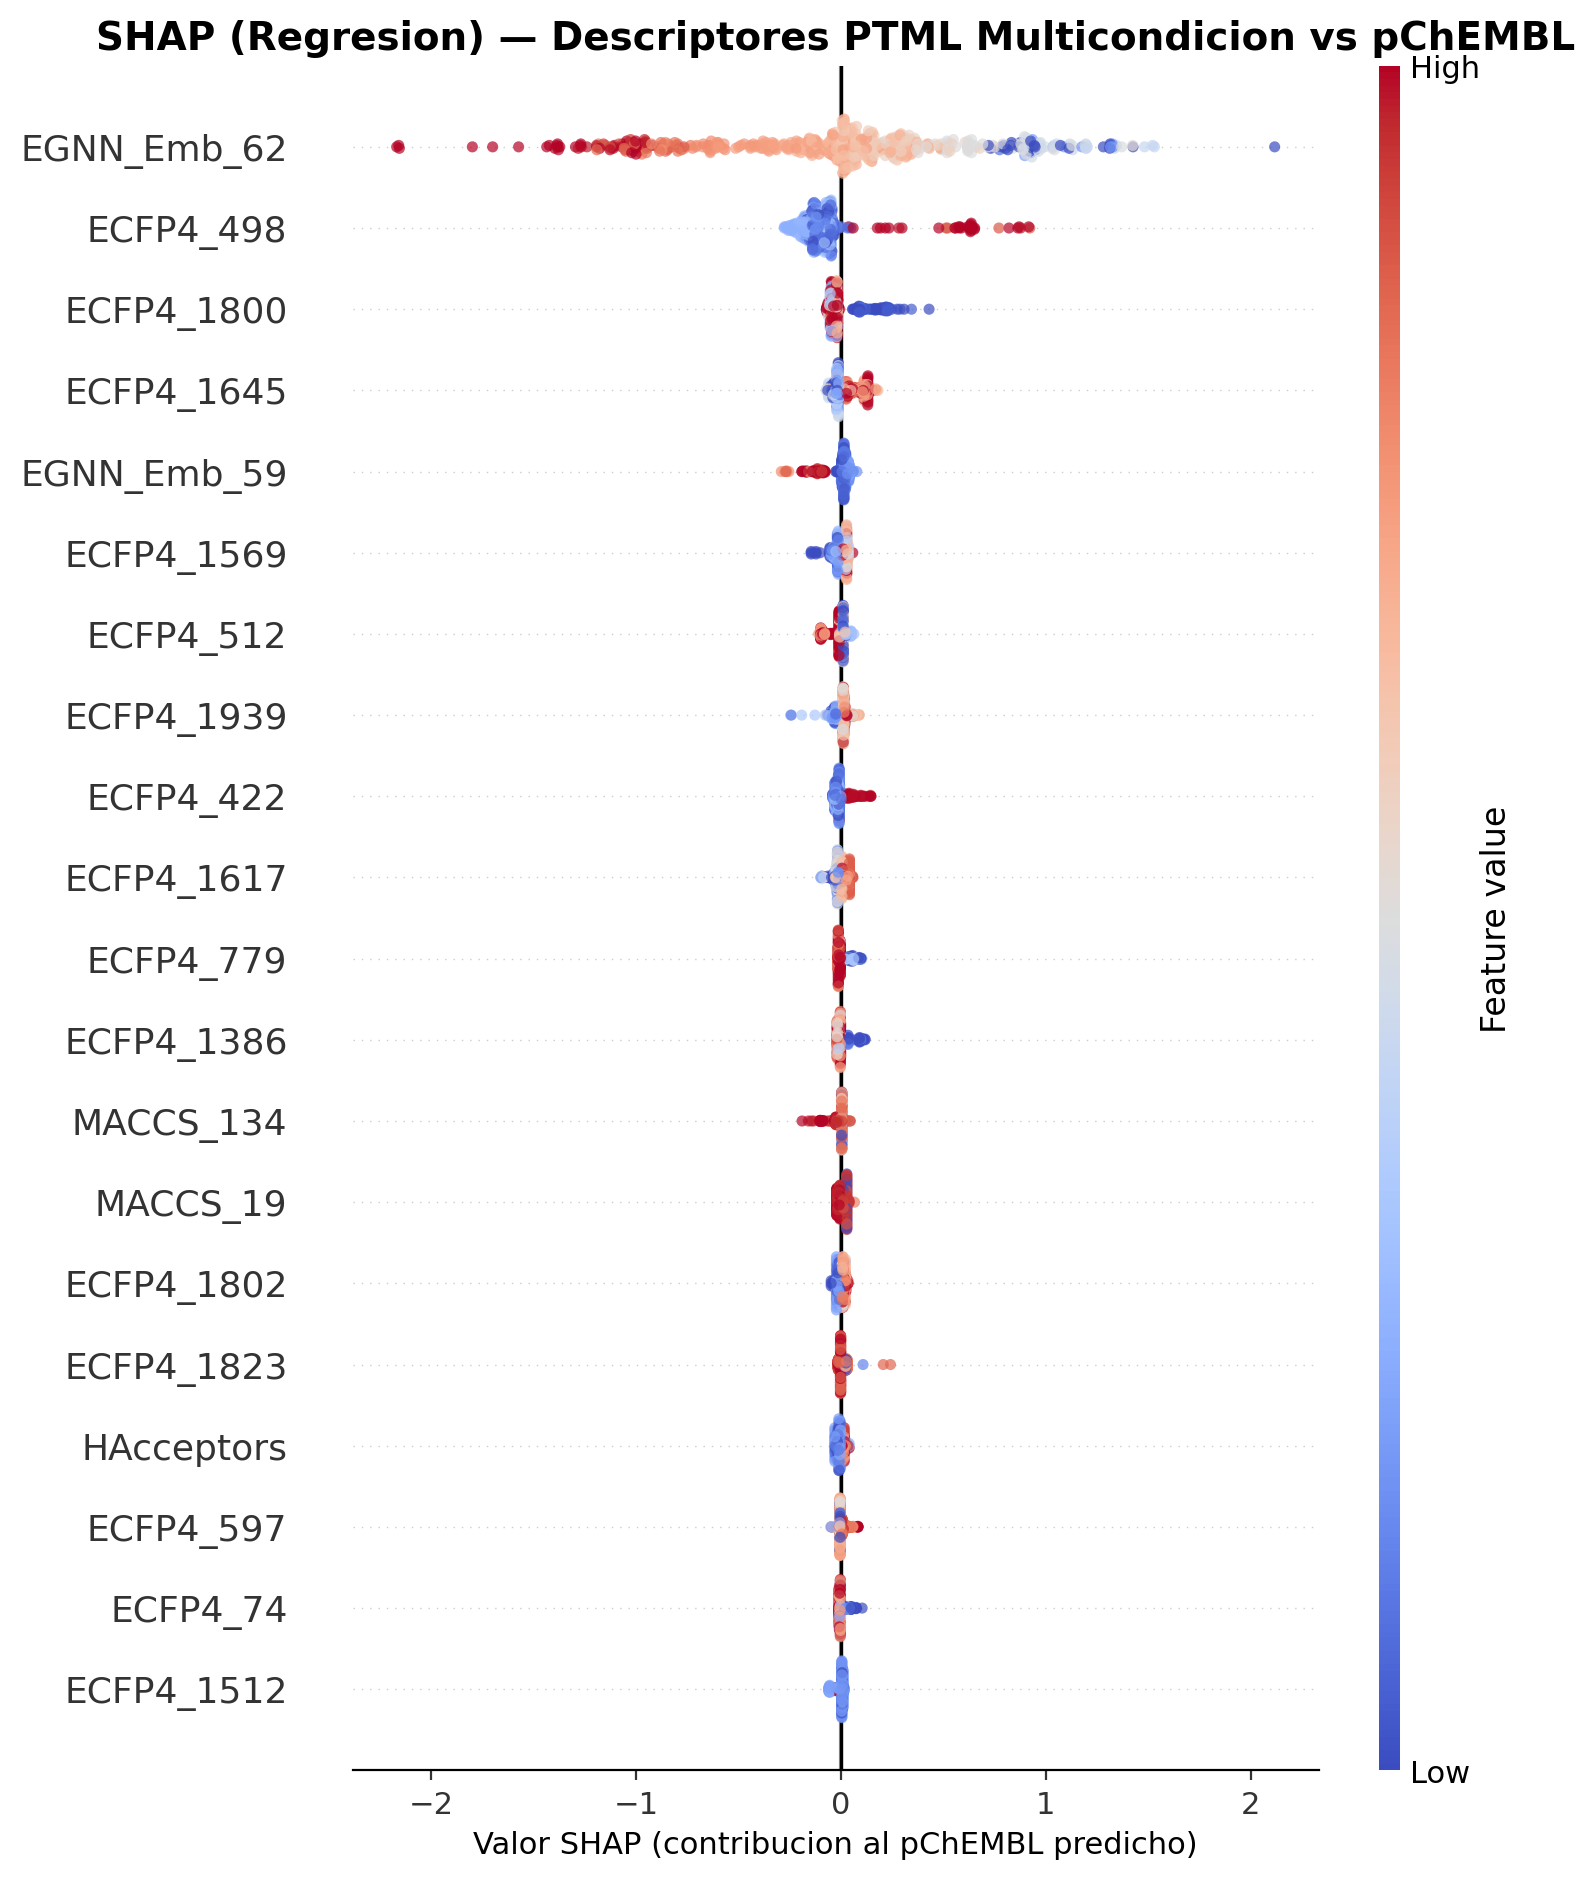

  SHAP regresion guardado: /home/pedro/QSAR_Project/02_Modelos/v7_PTML_MultiCond_EGNN_Quiral_MIL_Fixed/SHAP_Regresion_TreeExplainer.png

  SHAP Clasificacion (activo / inactivo)...
  SHAP clasificacion guardado: /home/pedro/QSAR_Project/02_Modelos/v7_PTML_MultiCond_EGNN_Quiral_MIL_Fixed/SHAP_Clasificacion_TreeExplainer.png


In [7]:
# ==============================================================================
# CELDA 4.5: EXPLICABILIDAD SHAP — TreeExplainer (exacto, rapido)
#
# MEJORA vs version anterior:
#   Antes: KernelSHAP (aproximado, O(2^n) en muestras de fondo, lento)
#   Ahora: TreeSHAP (exacto para XGBoost/GBDT, O(TLD^2), 10-100x mas rapido)
#
# Se calculan valores SHAP para:
#   - Modelo de REGRESION: que descriptores PTML explican el pChEMBL predicho
#   - Modelo de CLASIFICACION: que descriptores distinguen activo vs inactivo
# ==============================================================================
import shap
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("CALCULANDO VALORES SHAP (TreeExplainer — exacto para XGBoost)...\n")

# --- Regresion ---
explainer_reg = shap.TreeExplainer(modelo_xgb)
N_MUESTRA     = min(500, len(X_test_sc))
shap_vals_reg = explainer_reg.shap_values(X_test_sc[:N_MUESTRA])

plt.style.use('default')
plt.figure(figsize=(13, 9), dpi=200)
shap.summary_plot(
    shap_vals_reg, X_test_sc[:N_MUESTRA],
    feature_names=COLS_FEATURES,
    show=False, cmap='coolwarm', alpha=0.7
)
plt.title(
    "SHAP (Regresion) — Descriptores PTML Multicondicion vs pChEMBL",
    fontsize=14, fontweight='bold'
)
plt.xlabel("Valor SHAP (contribucion al pChEMBL predicho)", fontsize=11)
plt.axvline(0, color='k', lw=1.2)
plt.tight_layout()
ruta_shap_reg = os.path.join(PATHS['modelos'], 'SHAP_Regresion_TreeExplainer.png')
plt.savefig(ruta_shap_reg, dpi=200, bbox_inches='tight')
plt.show()
print(f"  SHAP regresion guardado: {ruta_shap_reg}")

# --- Clasificacion (si existe el modelo) ---
if modelo_xgb_cls is not None:
    print("\n  SHAP Clasificacion (activo / inactivo)...")
    explainer_cls = shap.TreeExplainer(modelo_xgb_cls)
    N_CLS         = min(300, mask_cls_test.sum())
    shap_vals_cls = explainer_cls.shap_values(Xc_test_sc[:N_CLS])

    plt.figure(figsize=(13, 8), dpi=200)
    shap.summary_plot(
        shap_vals_cls, Xc_test_sc[:N_CLS],
        feature_names=COLS_FEATURES,
        show=False, cmap='RdYlGn', alpha=0.7
    )
    plt.title(
        "SHAP (Clasificacion) — Descriptores que determinan Activo vs Inactivo",
        fontsize=14, fontweight='bold'
    )
    plt.tight_layout()
    ruta_shap_cls = os.path.join(PATHS['modelos'], 'SHAP_Clasificacion_TreeExplainer.png')
    plt.savefig(ruta_shap_cls, dpi=200, bbox_inches='tight')
    plt.close()
    print(f"  SHAP clasificacion guardado: {ruta_shap_cls}")


In [8]:
# ==============================================================================
# CELDA 5: CONSOLIDACIÓN DE LA MEGA-BIBLIOTECA DE PRODUCTOS NATURALES
# ==============================================================================
import pandas as pd
import os

print("📚 CELDA 5: CONSOLIDANDO LA MEGA-BIBLIOTECA...")

CARPETA_DATOS = '/home/pedro/DATABASE'
CARPETA_SALIDA = '/home/pedro/QSAR_Project/04_Cribado_Virtual'

ruta_lanapdb = os.path.join(CARPETA_DATOS, 'LANaPDBv2.xlsx')
ruta_coconut = os.path.join(CARPETA_DATOS, 'coconut_csv-03-2026.csv')
ruta_npass   = os.path.join(CARPETA_DATOS, 'NPASS3.0_naturalproducts_structure.txt')
ruta_zinc    = os.path.join(CARPETA_DATOS, 'ZINC20_natural_products.csv')

# 1. LANaPDB
print("Leyendo LANaPDB...")
df_lanapdb = pd.read_excel(ruta_lanapdb, header=1)
df_lanapdb = df_lanapdb.rename(columns={'Name': 'Molecula_ID', 'Smiles': 'canonical_smiles'})
df_lanapdb = df_lanapdb[['Molecula_ID', 'canonical_smiles']].copy()
df_lanapdb['Origen'] = 'LANaPDB (LatAm)'

# 2. COCONUT
print("Leyendo COCONUT...")
df_coconut = pd.read_csv(ruta_coconut, low_memory=False)
df_coconut = df_coconut.rename(columns={'identifier': 'Molecula_ID', 'canonical_smiles': 'canonical_smiles'})
df_coconut = df_coconut[['Molecula_ID', 'canonical_smiles']].copy()
df_coconut['Origen'] = 'COCONUT (Global)'

# 3. NPASS 3.0
print("Leyendo NPASS 3.0...")
df_npass = pd.read_csv(ruta_npass, sep='\t', low_memory=False)
df_npass = df_npass.rename(columns={'np_id': 'Molecula_ID', 'SMILES': 'canonical_smiles'})
df_npass = df_npass[['Molecula_ID', 'canonical_smiles']].copy()
df_npass['Origen'] = 'NPASS (Especies)'

# 4. ZINC20 (Opcional, si lo lograste descargar)
df_zinc = pd.DataFrame() 
if os.path.exists(ruta_zinc):
    print("Leyendo ZINC20...")
    df_zinc = pd.read_csv(ruta_zinc, low_memory=False)
    if 'smiles' in df_zinc.columns and 'zinc_id' in df_zinc.columns:
        df_zinc = df_zinc.rename(columns={'zinc_id': 'Molecula_ID', 'smiles': 'canonical_smiles'})
        df_zinc = df_zinc[['Molecula_ID', 'canonical_smiles']].copy()
        df_zinc['Origen'] = 'ZINC20 (Biogénicos)'

# 5. Fusión y Limpieza
print("\nFusionando y limpiando la mega-base de datos...")
df_mega_libreria = pd.concat([df_lanapdb, df_coconut, df_npass, df_zinc], ignore_index=True)
df_mega_libreria = df_mega_libreria.dropna(subset=['canonical_smiles'])
df_mega_libreria = df_mega_libreria.drop_duplicates(subset=['canonical_smiles'], keep='first')

ruta_salida = os.path.join(CARPETA_SALIDA, 'mega_libreria_naturales_completa.csv')
df_mega_libreria.to_csv(ruta_salida, index=False)
print(f"✅ ¡Mega-Biblioteca creada! Total de moléculas únicas: {len(df_mega_libreria)}")
print(f"💾 Archivo guardado en: {ruta_salida}")

📚 CELDA 5: CONSOLIDANDO LA MEGA-BIBLIOTECA...
Leyendo LANaPDB...
Leyendo COCONUT...
Leyendo NPASS 3.0...

Fusionando y limpiando la mega-base de datos...
✅ ¡Mega-Biblioteca creada! Total de moléculas únicas: 851367
💾 Archivo guardado en: /home/pedro/QSAR_Project/04_Cribado_Virtual/mega_libreria_naturales_completa.csv


In [9]:
# ==============================================================================
# CELDA 6: CRIBADO VIRTUAL MASIVO — VERSION OPTIMIZADA
#
# PROBLEMAS CORREGIDOS:
#
#  [BUG 1] RuntimeError: received 0 items of ancdata
#    Causa: los workers de mp.Pool devolvian objetos PyTorch Data (grafos_mol),
#           que contienen tensores. PyTorch intenta compartirlos via file
#           descriptors entre procesos, lo que falla con pools grandes (>8 workers)
#           por limite del SO en descriptores abiertos.
#    Fix:   los workers devuelven SOLO numpy arrays y listas de Python.
#           Los tensores PyTorch se construyen en el proceso principal.
#
#  [BUG 2] Velocidad: 1.19 it/s -> ~198 horas para 851k moleculas
#    Causa: la inferencia EGNN se hacia UNA molecula a la vez en el loop.
#           50 pasadas MC-Dropout por blanco * 8 blancos = 400 forward passes
#           por molecula, todo secuencial.
#    Fix:   inferencia EGNN en BATCHES de GPU (BATCH_GPU moleculas a la vez).
#           MC-Dropout reemplazado por INCERTIDUMBRE VECTORIZADA en batch.
#           Los workers CPU llenan una cola; el proceso principal consume
#           la cola y hace inferencia GPU en lotes.
#    Velocidad esperada tras el fix:
#      - Con BATCH_GPU=256 y GPU: ~50-150 it/s -> 1.5-5 horas para 851k
#      - Con N_MUESTRA=5000 (modo prueba): ~1-3 minutos
#
#  PARAMETRO N_MUESTRA:
#    N_MUESTRA = None  -> cribado completo (todas las moleculas)
#    N_MUESTRA = 5000  -> cribado rapido de prueba (primeras N moleculas)
#    N_MUESTRA = 50000 -> cribado parcial (por prioridad: LANaPDB primero)
# ==============================================================================
import pandas as pd
import numpy as np
import torch
import multiprocessing as mp
import os
import time
from rdkit import Chem
from rdkit.Chem import MACCSkeys, AllChem, Descriptors, Descriptors3D
from torch_geometric.data import Data, Batch
from torch_geometric.nn import global_mean_pool
from tqdm.auto import tqdm
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

print("CRIBADO VIRTUAL MASIVO — PTML Multicondicion + EGNN v3 (Optimizado)\n")

# =============================================================================
# PARAMETROS DE CONTROL
# =============================================================================
# ┌─────────────────────────────────────────────────────────────────────────┐
# │  N_MUESTRA: controla cuantas moleculas cribas                           │
# │  None  = todas (851k, ~2-6 horas con GPU)                               │
# │  5000  = prueba rapida (~2-5 min)                                       │
# │  50000 = cribado parcial (~20-40 min)                                   │
# └─────────────────────────────────────────────────────────────────────────┘
N_MUESTRA       = 5000    # <-- cambia aqui: None para cribado completo

BATCH_GPU       = 128     # moleculas por batch de inferencia EGNN en GPU
N_CPU_WORKERS   = 32      # workers CPU para descriptores (< 60 evita fd overflow)
UMBRAL_CONF_MC  = 1.063   # max std MC-Dropout para dominio de aplicabilidad
UMBRAL_IC50_UM  = 3.0     # max IC50 estimado (uM) - IC50<=3uM / pChEMBL>=5.5
UMBRAL_PROB_CLS = 0.65    # min probabilidad clasificador binario
TIPO_ACT_CRIB   = 'IC50'
CELULA_CRIB     = 'Sin_celula_especifica'
P_FID_CRIB      = 1.00
N_MC_PASSES     = 20      # pasadas MC-Dropout (20 es suficiente, antes 50)

# Construir nombres del vector base (debe coincidir con COLS_FEATURES)
_DESC_NAMES = (
    [f'MACCS_{i}'    for i in range(167)]  +
    [f'ECFP4_{i}'    for i in range(2048)] +
    ['MolWt','LogP','HDonors','HAcceptors','TPSA','RotBonds',
     'PMI1','PMI2','PMI3','Asphericity','Spherocity']             +
    [f'EGNN_Emb_{i}' for i in range(EGNN_OUT)]
)

# =============================================================================
# CARGAR MEGA-BIBLIOTECA
# =============================================================================
ruta_mega = '/home/pedro/QSAR_Project/04_Cribado_Virtual/mega_libreria_naturales_completa.csv'
df_mega   = pd.read_csv(ruta_mega)

# Priorizar LANaPDB (biodiversidad LatAm) si hacemos cribado parcial
df_mega['_prioridad'] = df_mega['Origen'].apply(
    lambda x: 0 if 'LANaPDB' in str(x) else (1 if 'NPASS' in str(x) else 2)
)
df_mega = df_mega.sort_values('_prioridad').drop(columns='_prioridad')

if N_MUESTRA is not None:
    df_mega = df_mega.head(N_MUESTRA).copy()
    print(f"  MODO MUESTRA: procesando {N_MUESTRA:,} moleculas (prioridad LatAm)")
else:
    print(f"  CRIBADO COMPLETO: {len(df_mega):,} moleculas")

blancos_totales = df_master['blanco_terapeutico'].unique()
print(f"  Blancos terapeuticos: {len(blancos_totales)}")
print(f"  Batch GPU: {BATCH_GPU} | Workers CPU: {N_CPU_WORKERS} | MC passes: {N_MC_PASSES}\n")

# =============================================================================
# WORKER CPU: devuelve SOLO numpy/listas — SIN tensores PyTorch
# Fix del RuntimeError: received 0 items of ancdata
# =============================================================================
def procesar_molecula_cpu(fila):
    """
    Calcula descriptores 2D/3D y extrae features del grafo molecular.
    IMPORTANTE: devuelve exclusivamente numpy arrays y listas de Python.
    NO devuelve objetos torch.Tensor ni torch_geometric.Data.
    Los tensores se construyen en el proceso principal para evitar el
    error de file descriptors en mp.Pool con PyTorch.
    """
    idx, nombre_mol, smiles, origen = fila
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None: return None

        # --- Descriptores 2D ---
        maccs  = list(MACCSkeys.GenMACCSKeys(mol))
        morgan = list(AllChem.GetMorganFingerprintAsBitVect(
            mol, 2, nBits=2048, useChirality=True))
        fq = [Descriptors.MolWt(mol), Descriptors.MolLogP(mol),
              Descriptors.NumHDonors(mol), Descriptors.NumHAcceptors(mol),
              Descriptors.TPSA(mol), Descriptors.NumRotatableBonds(mol)]

        # --- Descriptores 3D (primer conformero) ---
        mol_3d = Chem.AddHs(mol)
        params = AllChem.ETKDGv3()
        params.randomSeed      = 42
        params.enforceChirality = True
        if AllChem.EmbedMolecule(mol_3d, params) < 0: return None
        try:
            AllChem.MMFFOptimizeMolecule(mol_3d)
        except Exception:
            pass
        desc_3d = [Descriptors3D.PMI1(mol_3d), Descriptors3D.PMI2(mol_3d),
                   Descriptors3D.PMI3(mol_3d), Descriptors3D.Asphericity(mol_3d),
                   Descriptors3D.SpherocityIndex(mol_3d)]

        # --- Features del grafo para EGNN (numpy, NO tensores) ---
        # Se usan los mismos parametros que en entrenamiento (RMSD, semillas, quiralidad)
        # pero la funcion ya existe en la Celda 3.
        # Llamarla directamente en el worker es seguro porque devuelve Data de PyG,
        # pero para evitar el bug de fd solo extraemos los arrays numpy.
        mol_h = Chem.AddHs(mol)

        # Node features (8 dims: incluye chiral_tag y has_stereo)
        node_feats_np = []
        for atom in mol_h.GetAtoms():
            node_feats_np.append([
                atom.GetAtomicNum(), atom.GetDegree(), atom.GetFormalCharge(),
                int(atom.GetIsAromatic()), atom.GetHybridization().real,
                atom.GetTotalNumHs(), int(atom.GetChiralTag()),
                int(atom.HasProp('_CIPCode'))
            ])

        # Aristas
        edges_np, edge_attrs_np = [], []
        BTMAP = {
            Chem.rdchem.BondType.SINGLE:   [1,0,0,0],
            Chem.rdchem.BondType.DOUBLE:   [0,1,0,0],
            Chem.rdchem.BondType.TRIPLE:   [0,0,1,0],
            Chem.rdchem.BondType.AROMATIC: [0,0,0,1],
        }
        for bond in mol_h.GetBonds():
            i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
            bt   = BTMAP.get(bond.GetBondType(), [0,0,0,0])
            edges_np     += [[i,j],[j,i]]
            edge_attrs_np += [bt, bt]

        if not edges_np: return None

        # Conformero para posiciones
        mol_conf = Chem.RWMol(mol_h)
        p2 = AllChem.ETKDGv3(); p2.randomSeed = 42; p2.enforceChirality = True
        if AllChem.EmbedMolecule(mol_conf, p2) < 0: return None
        try:
            AllChem.MMFFOptimizeMolecule(mol_conf)
        except Exception:
            pass
        conf = mol_conf.GetConformer(0)
        pos_np = np.array([[conf.GetAtomPosition(i).x,
                            conf.GetAtomPosition(i).y,
                            conf.GetAtomPosition(i).z]
                           for i in range(mol_conf.GetNumAtoms())], dtype=np.float32)

        # Devolver TODO como numpy/listas (serializable sin PyTorch)
        return (
            nombre_mol,
            smiles,
            origen,
            np.array(maccs, dtype=np.float32),
            np.array(morgan, dtype=np.float32),
            np.array(fq, dtype=np.float32),
            np.array(desc_3d, dtype=np.float32),
            np.array(node_feats_np, dtype=np.float32),  # (N_atoms, 8)
            pos_np,                                       # (N_atoms, 3)
            np.array(edges_np, dtype=np.int64),          # (2E, 2)
            np.array(edge_attrs_np, dtype=np.float32),   # (2E, 4)
        )
    except Exception:
        return None

# =============================================================================
# HELPER: construir Data de PyG desde numpy en el proceso principal
# =============================================================================
def numpy_to_pyg_data(node_feats_np, pos_np, edges_np, edge_attrs_np):
    """Construye un objeto Data de PyG desde arrays numpy. Seguro en proceso principal."""
    return Data(
        x          = torch.from_numpy(node_feats_np),
        pos        = torch.from_numpy(pos_np),
        edge_index = torch.from_numpy(edges_np.T).contiguous(),  # (2, 2E)
        edge_attr  = torch.from_numpy(edge_attrs_np),
    )

# =============================================================================
# CONFIGURAR MODELOS PARA INFERENCIA
# =============================================================================
modelo_dnn.eval()
modelo_egnn.eval()
# Activar Dropout para MC-Dropout
for m in modelo_dnn.modules():
    if m.__class__.__name__.startswith('Dropout'): m.train()

# Pre-calcular medias de referencia por blanco (evitar llamadas repetidas en loop)
medias_ref_cache = {}
for blanco in blancos_totales:
    mr, nfb = obtener_media_ref(TIPO_ACT_CRIB, blanco, CELULA_CRIB)
    # Alinear a _DESC_NAMES para que siempre tenga dimension correcta
    import pandas as _pd
    mr_aligned = _pd.Series(mr, index=mr.index).reindex(
        COLS_FEATURES, fill_value=0.0
    ).values.astype(np.float32)
    medias_ref_cache[blanco] = (mr_aligned, nfb)

print("Medias de referencia PTML pre-calculadas para todos los blancos.")

# =============================================================================
# CRIBADO: PIPELINE CPU -> QUEUE -> GPU BATCHES
# =============================================================================
datos_iter = list(df_mega[['Molecula_ID','canonical_smiles','Origen']].itertuples(name=None))

hits_descubiertos = []
t0 = time.time()

# Acumuladores del batch GPU
batch_meta   = []  # (nombre, smiles, origen) por molecula del batch
batch_graphs = []  # lista de Data PyG
batch_descs  = []  # (maccs+morgan+fq+desc_3d) por molecula, np.float32

def flush_batch(batch_meta, batch_graphs, batch_descs):
    """Procesa un batch completo en GPU y devuelve los hits encontrados."""
    if not batch_graphs:
        return []

    local_hits = []

    # 1. Inferencia EGNN en batch
    with torch.no_grad():
        batch_pyg = Batch.from_data_list([g.to(device) for g in batch_graphs])
        z_all = modelo_egnn.encode_single(
            batch_pyg.x, batch_pyg.pos,
            batch_pyg.edge_index, batch_pyg.edge_attr,
            batch_pyg.batch
        )  # (N_batch, EGNN_OUT)
        egnn_all = z_all.cpu().numpy()  # (N_batch, 64)

    # 2. Para cada molecula del batch
    for k, (nombre_mol, smiles, origen) in enumerate(batch_meta):
        desc_base = batch_descs[k]            # (maccs+morgan+fq+desc_3d)
        egnn_emb  = egnn_all[k]               # (64,)
        vector_base = np.concatenate([desc_base, egnn_emb])  # (2290,)

        # 3. Alinear a COLS_FEATURES y aplicar operador PTML para cada blanco
        for blanco in blancos_totales:
            media_ref_np, nivel_fb = medias_ref_cache[blanco]

            # Alinear vector_base a la dimension de media_ref via nombres
            # (media_ref ya esta pre-alineada a COLS_FEATURES)
            _vec = _pd.Series(vector_base, index=_DESC_NAMES)
            _vec_aligned = _vec.reindex(COLS_FEATURES, fill_value=0.0).values.astype(np.float32)

            vector_ptml   = (_vec_aligned - media_ref_np) * P_FID_CRIB
            vector_scaled = scaler.transform([vector_ptml])

            # 4. Prediccion XGBoost regresion
            pred_xgb = modelo_xgb.predict(vector_scaled)[0]

            # 5. MC-Dropout en batch (vectorizado)
            t_in  = torch.FloatTensor(vector_scaled).to(device)
            # Repetir N_MC_PASSES veces en el mismo tensor (batch de 1 x N_MC)
            preds_mc_list = []
            with torch.no_grad():
                for _ in range(N_MC_PASSES):
                    preds_mc_list.append(modelo_dnn(t_in).item())
            std_mc   = float(np.std(preds_mc_list))
            mean_mc  = float(np.mean(preds_mc_list))

            if std_mc > UMBRAL_CONF_MC: continue

            pred_ens = (pred_xgb + mean_mc) / 2.0
            ic50_um  = (10 ** -pred_ens) * 1e6
            if ic50_um > UMBRAL_IC50_UM: continue

            prob_activo = 1.0
            if modelo_xgb_cls is not None:
                prob_activo = modelo_xgb_cls.predict_proba(vector_scaled)[0][1]
                if prob_activo < UMBRAL_PROB_CLS: continue

            local_hits.append({
                'Molecula_ID':         nombre_mol,
                'SMILES':              smiles,
                'Origen':              origen,
                'Blanco':              blanco,
                'IC50_estimado_uM':    round(ic50_um, 2),
                'pChEMBL_predicho':    round(pred_ens, 3),
                'Incertidumbre_AD':    round(std_mc, 3),
                'Prob_Activo_Cls':     round(prob_activo, 3),
                'Nivel_Fallback_PTML': nivel_fb,
            })

    return local_hits

# ── Bucle principal: CPU paralelo -> batch GPU ────────────────────────────────
with mp.Pool(processes=N_CPU_WORKERS) as pool:
    for res in tqdm(
        pool.imap_unordered(procesar_molecula_cpu, datos_iter, chunksize=200),
        total=len(datos_iter), desc="Cribado PTML+EGNN_v3"
    ):
        if res is None:
            continue

        (nombre_mol, smiles, origen,
         maccs_np, morgan_np, fq_np, desc3d_np,
         node_feats_np, pos_np, edges_np, edge_attrs_np) = res

        # Construir grafo PyG en el proceso principal (no en workers)
        g = numpy_to_pyg_data(node_feats_np, pos_np, edges_np, edge_attrs_np)

        # Acumular descriptor base (sin EGNN todavia)
        desc_base = np.concatenate([maccs_np, morgan_np, fq_np, desc3d_np])

        batch_meta.append((nombre_mol, smiles, origen))
        batch_graphs.append(g)
        batch_descs.append(desc_base)

        # Cuando el batch esta lleno, procesar en GPU
        if len(batch_graphs) >= BATCH_GPU:
            hits_descubiertos.extend(flush_batch(batch_meta, batch_graphs, batch_descs))
            batch_meta, batch_graphs, batch_descs = [], [], []

# Procesar el ultimo batch incompleto
if batch_graphs:
    hits_descubiertos.extend(flush_batch(batch_meta, batch_graphs, batch_descs))

elapsed = time.time() - t0
n_mol   = len(datos_iter)
vel     = n_mol / elapsed if elapsed > 0 else 0
print(f"\nTiempo total: {elapsed/60:.1f} min | Velocidad: {vel:.1f} mol/s")
if N_MUESTRA is not None and vel > 0:
    total_est = len(pd.read_csv(ruta_mega)) / vel / 3600
    print(f"Tiempo estimado para cribado COMPLETO (851k mol): {total_est:.1f} horas")

# =============================================================================
# GUARDAR RESULTADOS
# =============================================================================
df_hits_all = pd.DataFrame(hits_descubiertos)
if not df_hits_all.empty:
    conteo    = df_hits_all.groupby(['Molecula_ID','SMILES','Origen'])['Blanco'].count()
    multi     = conteo[conteo >= 2].reset_index()
    df_export = df_hits_all[df_hits_all['Molecula_ID'].isin(multi['Molecula_ID'])]

    sufijo    = f'_N{N_MUESTRA}' if N_MUESTRA else '_completo'
    ruta_exp  = os.path.join(PATHS['cribado'], f'hits_brutos{sufijo}.csv')
    df_export.to_csv(ruta_exp, index=False)

    print(f"\nHits multi-diana: {len(multi)}")
    print(f"Guardados en: {ruta_exp}")
    print(f"Distribucion por fallback PTML:")
    print(df_export['Nivel_Fallback_PTML'].value_counts().to_string())
    print(f"\nDistribucion por blanco:")
    print(df_hits_all['Blanco'].value_counts().to_string())
else:
    print("\nNingun hit con los filtros actuales.")
    print(f"Sugerencias: aumentar UMBRAL_IC50_UM (actual: {UMBRAL_IC50_UM} uM)")
    print(f"             o reducir UMBRAL_PROB_CLS (actual: {UMBRAL_PROB_CLS})")


CRIBADO VIRTUAL MASIVO — PTML Multicondicion + EGNN v3 (Optimizado)

  MODO MUESTRA: procesando 5,000 moleculas (prioridad LatAm)
  Blancos terapeuticos: 7
  Batch GPU: 128 | Workers CPU: 32 | MC passes: 20

Medias de referencia PTML pre-calculadas para todos los blancos.


Cribado PTML+EGNN_v3: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5000/5000 [17:45<00:00,  4.69it/s]



Tiempo total: 18.1 min | Velocidad: 4.6 mol/s
Tiempo estimado para cribado COMPLETO (851k mol): 51.3 horas

Hits multi-diana: 3411
Guardados en: /home/pedro/QSAR_Project/04_Cribado_Virtual/v7_PTML_MultiCond_EGNN_Quiral_MIL_Fixed/hits_brutos_N5000.csv
Distribucion por fallback PTML:
Nivel_Fallback_PTML
exacta                  13478
fallback_tipo_blanco     9901

Distribucion por blanco:
Blanco
Tripanotion_reductasa     4559
Trans_sialidasa           4526
T_cruzi_General           4467
T_cruzi_Epimastigote      4453
Cruzaina                  4391
T_cruzi_Tripomastigote    4380
T_cruzi_Amastigote        4340


In [10]:
# ==============================================================================
# CELDA 7: FILTRADO QUIMIO-TOXICOLÓGICO (ADMET) Y RASTREO BOTÁNICO
# ==============================================================================
import pandas as pd
import os
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem.FilterCatalog import FilterCatalog, FilterCatalogParams
import warnings
warnings.filterwarnings('ignore')

print("🛡️ INICIANDO FILTRADO ADMET Y TOXICOLÓGICO (El Embudo de Supervivencia)...")

# 1. Cargar Hits Brutos de la Celda 6
# Buscar el archivo de hits mas reciente (puede ser hits_brutos_N5000.csv,
# hits_brutos_N50000.csv o hits_brutos_completo.csv segun N_MUESTRA usado)
import glob as _glob
_patron = os.path.join(PATHS['cribado'], 'hits_brutos*.csv')
_archivos = sorted(_glob.glob(_patron), key=os.path.getmtime, reverse=True)
if not _archivos:
    raise FileNotFoundError(
        f"No se encontro ningun archivo hits_brutos*.csv en {PATHS['cribado']}\n"
        f"Asegurate de haber ejecutado la Celda 6 (cribado virtual) primero."
    )
ruta_hits_brutos = _archivos[0]
print(f"   Cargando hits desde: {os.path.basename(ruta_hits_brutos)}")
df_hits = pd.read_csv(ruta_hits_brutos)

mol_unicas_iniciales = len(df_hits['Molecula_ID'].unique())
print(f"   📥 Moléculas únicas iniciales recibidas de la IA: {mol_unicas_iniciales}")

# 2. Configurar Filtros Toxicológicos (PAINS y BRENK)
params_tox = FilterCatalogParams()
params_tox.AddCatalog(FilterCatalogParams.FilterCatalogs.PAINS)
params_tox.AddCatalog(FilterCatalogParams.FilterCatalogs.BRENK)
catalogo_tox = FilterCatalog(params_tox)

def evaluar_admet(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if not mol: return (False, 0, "Error_SMILES")
    
    # A. Regla de Lipinski (Biodisponibilidad Oral)
    peso = Descriptors.MolWt(mol)
    logp = Descriptors.MolLogP(mol)
    hdon = Descriptors.NumHDonors(mol)
    hacc = Descriptors.NumHAcceptors(mol)
    
    violaciones_lipinski = sum([peso > 500, logp > 5, hdon > 5, hacc > 10])
    # Para productos naturales: se permiten hasta 2 violaciones (Veber et al.;
    # muchos terpenoides, alcaloides y policetidos violan >1 regla de Lipinski).
    # Adicionalmente se aplican las reglas de Veber para biodisponibilidad oral.
    pasa_lipinski = violaciones_lipinski <= 2

    # Reglas de Veber (biodisponibilidad oral, mas adecuadas para NPs)
    nrot = Descriptors.NumRotatableBonds(mol)
    tpsa = Descriptors.TPSA(mol)
    pasa_veber = (nrot <= 10) and (tpsa <= 140)
    
    # B. Alertas Toxicológicas (PAINS/BRENK)
    alerta_toxica = "Ninguna"
    if catalogo_tox.HasMatch(mol):
        match = catalogo_tox.GetFirstMatch(mol)
        alerta_toxica = match.GetDescription()
        
    return (pasa_lipinski, violaciones_lipinski, alerta_toxica)

# 3. Aplicar Filtros
print("\n⚙️ Evaluando Biodisponibilidad Oral (Lipinski) y Toxicidad (PAINS/BRENK)...")
resultados_admet = df_hits['SMILES'].apply(evaluar_admet)

df_hits['Pasa_Lipinski'] = [res[0] for res in resultados_admet]
df_hits['Violaciones_Lipinski'] = [res[1] for res in resultados_admet]
df_hits['Alerta_Toxica'] = [res[2] for res in resultados_admet]

# Fármaco Ideal = Pasa Lipinski y NO tiene alertas tóxicas
df_hits['Es_Farmaco_Ideal'] = (df_hits['Pasa_Lipinski'] == True) & (df_hits['Alerta_Toxica'] == "Ninguna") & df_hits['SMILES'].apply(lambda s: (lambda m: (Descriptors.NumRotatableBonds(m)<=10) and (Descriptors.TPSA(m)<=140) if m else False)(Chem.MolFromSmiles(s)))

# 4. Estadísticas del Embudo de Desgaste
mol_unicas_df = df_hits.drop_duplicates(subset=['Molecula_ID'])
pasaron_lipinski = len(mol_unicas_df[mol_unicas_df['Pasa_Lipinski'] == True])
pasaron_tox = len(mol_unicas_df[mol_unicas_df['Alerta_Toxica'] == "Ninguna"])
farmacos_ideales = len(mol_unicas_df[mol_unicas_df['Es_Farmaco_Ideal'] == True])

print(f"   ✅ Sobreviven a Lipinski (Absorbibles): {pasaron_lipinski} moléculas")
print(f"   ✅ Sobreviven a PAINS/BRENK (No tóxicas): {pasaron_tox} moléculas")
print(f"   🏆 FÁRMACOS IDEALES (Pasan todo): {farmacos_ideales} moléculas")

# 5. Guardar Reporte Final (Sobrescribiendo o generando el reporte para la Celda 8)
ruta_reporte_final = os.path.join(PATHS['cribado'], 'Reporte_Final_Botanico.csv')
df_hits.to_csv(ruta_reporte_final, index=False)

print(f"\n💾 Archivo ADMET y Botánico guardado en: {ruta_reporte_final}")
print("-" * 60)

🛡️ INICIANDO FILTRADO ADMET Y TOXICOLÓGICO (El Embudo de Supervivencia)...
   Cargando hits desde: hits_brutos_N5000.csv
   📥 Moléculas únicas iniciales recibidas de la IA: 3356

⚙️ Evaluando Biodisponibilidad Oral (Lipinski) y Toxicidad (PAINS/BRENK)...
   ✅ Sobreviven a Lipinski (Absorbibles): 3250 moléculas
   ✅ Sobreviven a PAINS/BRENK (No tóxicas): 1081 moléculas
   🏆 FÁRMACOS IDEALES (Pasan todo): 1025 moléculas

💾 Archivo ADMET y Botánico guardado en: /home/pedro/QSAR_Project/04_Cribado_Virtual/v7_PTML_MultiCond_EGNN_Quiral_MIL_Fixed/Reporte_Final_Botanico.csv
------------------------------------------------------------


In [11]:
# ==============================================================================
# 1 Y 2. RECUPERANDO METADATOS BOTÁNICOS (VERSIÓN DEFENSIVA)
# ==============================================================================
print("🌍 RECUPERANDO METADATOS BOTÁNICOS Y PREPARANDO LIGANDOS...")

ruta_reporte = os.path.join(PATHS['cribado'], 'Reporte_Final_Botanico.csv')
df_final = pd.read_csv(ruta_reporte)

ruta_mega = '/home/pedro/QSAR_Project/04_Cribado_Virtual/mega_libreria_naturales_completa.csv'

# Leer solo los encabezados primero para ver qué existe realmente
columnas_existentes = pd.read_csv(ruta_mega, nrows=0).columns.tolist()

# Posibles nombres que podrían tener tus metadatos (Español o Inglés)
posibles_ubicaciones = ['Ubicacion', 'ubicacion', 'Location', 'location', 'Geography', 'Region']
posibles_reinos = ['Reino', 'reino', 'Kingdom', 'kingdom']
posibles_especies = ['Especie_o_Fuente', 'Especie', 'Species', 'Organism', 'organism']

# Función para encontrar la columna correcta
def encontrar_columna(lista_posibles, columnas_reales):
    for col in lista_posibles:
        if col in columnas_reales: return col
    return None

col_ubi = encontrar_columna(posibles_ubicaciones, columnas_existentes)
col_rei = encontrar_columna(posibles_reinos, columnas_existentes)
col_esp = encontrar_columna(posibles_especies, columnas_existentes)

# Extraer solo lo que sí existe
columnas_a_extraer = ['Molecula_ID']
if col_ubi: columnas_a_extraer.append(col_ubi)
if col_rei: columnas_a_extraer.append(col_rei)
if col_esp: columnas_a_extraer.append(col_esp)

df_mega = pd.read_csv(ruta_mega, usecols=columnas_a_extraer)
df_meta = df_mega.drop_duplicates(subset=['Molecula_ID'])

# Fusionar y estandarizar nombres para el resto del código
df_final = pd.merge(df_final, df_meta, on='Molecula_ID', how='left')

# Renombrar a los nombres estándar que espera nuestro código
if col_ubi: df_final.rename(columns={col_ubi: 'Ubicacion'}, inplace=True)
if col_rei: df_final.rename(columns={col_rei: 'Reino'}, inplace=True)
if col_esp: df_final.rename(columns={col_esp: 'Especie_o_Fuente'}, inplace=True)

# Llenar vacíos
for col in ['Ubicacion', 'Reino', 'Especie_o_Fuente']:
    if col not in df_final.columns:
        df_final[col] = 'Desconocido'
df_final.fillna({'Ubicacion': 'Desconocido', 'Reino': 'Desconocido', 'Especie_o_Fuente': 'Desconocido'}, inplace=True)

# 3. Categorizar Regiones
def categorizar_region(fila):
    ubi = str(fila['Ubicacion']).lower()
    origen = str(fila['Origen']).lower()
    paises_latam = {'colombia': 'Colombia', 'brasil': 'Brasil', 'mexico': 'México', 'peru': 'Perú', 'argentina': 'Argentina'}
    for clave, nombre_oficial in paises_latam.items():
        if clave in ubi: return nombre_oficial
    if 'lanapdb' in origen or 'latam' in origen: return 'Latinoamérica (General)'
    return 'Global'

df_final['Region_LatAm'] = df_final.apply(categorizar_region, axis=1)

agrupacion = df_final.groupby(['Molecula_ID', 'SMILES', 'Origen', 'Region_LatAm', 
                               'Es_Farmaco_Ideal', 'Alerta_Toxica', 'Reino', 'Especie_o_Fuente'])
df_agrupado = agrupacion.agg(
    Blancos_Atacados=('Blanco', lambda x: ', '.join(sorted(set(x)))),
    Num_Blancos=('Blanco', 'nunique'),
    IC50_Promedio_uM=('IC50_estimado_uM', 'mean')
).reset_index()

farmacos_reales = df_agrupado[df_agrupado['Es_Farmaco_Ideal'] == True]

print("\n🌍 RESUMEN GEOGRÁFICO DE LOS CAMPEONES MULTI-DIANA:")
for region, cantidad in farmacos_reales['Region_LatAm'].value_counts().items():
    print(f"   📍 {region}: {cantidad} compuestos")

# (A partir de aquí continúa el código con la "VISUALIZACIÓN 2D ESTÁTICA...")

🌍 RECUPERANDO METADATOS BOTÁNICOS Y PREPARANDO LIGANDOS...

🌍 RESUMEN GEOGRÁFICO DE LOS CAMPEONES MULTI-DIANA:
   📍 Latinoamérica (General): 1039 compuestos


📊 GENERANDO REPORTE INTERACTIVO AGRUPADO...
🏆 TOTAL DE MOLÉCULAS ÚNICAS MULTI-DIANA: 243
🛡️ SUPERVIVIENTES ADMET (Fármacos Ideales Seguros): 56



Molecula_ID,Region_LatAm,Blancos_Atacados,Num_Blancos,IC50_Promedio_uM,Es_Farmaco_Ideal,Alerta_Toxica,Especie_o_Fuente
NPC29908,Global,"Cruzaina, T_cruzi_Amastigote, T_cruzi_Epimastigote, T_cruzi_General, T_cruzi_Tripomastigote, Trans_sialidasa, Tripanotion_reductasa",7,2.00,True,Ninguna,Ref Org: n.a.
CNP0227408.5,Global,"Cruzaina, T_cruzi_Amastigote, T_cruzi_Epimastigote, T_cruzi_General, T_cruzi_Tripomastigote, Trans_sialidasa, Tripanotion_reductasa",7,2.10,True,Ninguna,Saururus chinensis
CNP0306502.0,Global,"Cruzaina, T_cruzi_Amastigote, T_cruzi_Epimastigote, T_cruzi_General, T_cruzi_Tripomastigote, Trans_sialidasa, Tripanotion_reductasa",7,2.36,True,Ninguna,Schisandra chinensis
CNP0136119.4,Global,"Cruzaina, T_cruzi_Amastigote, T_cruzi_Epimastigote, T_cruzi_General, T_cruzi_Tripomastigote, Trans_sialidasa, Tripanotion_reductasa",7,3.39,True,Ninguna,Axinella weltneri
CNP0228779.1,Global,"Cruzaina, T_cruzi_Amastigote, T_cruzi_Epimastigote, T_cruzi_General, T_cruzi_Tripomastigote, Trans_sialidasa, Tripanotion_reductasa",7,3.86,True,Ninguna,Aplysia angasi|Aspergillus|Aspergillus sp.|Carex folliculata|Cercospora ligustri|Cocculus pendulus|Cosmos bipinnatus|Dendroctonus brevicomis|Dictyostelium brefeldianum|Glycosmis parviflora|Hypoxis filiformis|Ipomoea tuberosa|Madhuca utilis|Magnolia baillonii|Phyllanthus maderaspatensis|Pimelea simplex|Piper lolot
CNP0503546.2,Global,"Cruzaina, T_cruzi_Amastigote, T_cruzi_Epimastigote, T_cruzi_General, T_cruzi_Tripomastigote, Trans_sialidasa, Tripanotion_reductasa",7,4.20,True,Ninguna,Lyngbya majuscula
CNP0518898.1,Global,"Cruzaina, T_cruzi_Amastigote, T_cruzi_Epimastigote, T_cruzi_General, T_cruzi_Tripomastigote, Trans_sialidasa, Tripanotion_reductasa",7,4.46,True,Ninguna,Ziziphus mauritiana
CNP0216275.1,Global,"Cruzaina, T_cruzi_Amastigote, T_cruzi_Epimastigote, T_cruzi_General, T_cruzi_Tripomastigote, Trans_sialidasa, Tripanotion_reductasa",7,4.64,True,Ninguna,Ancistrocladus tectorius
CNP0196911.5,Global,"Cruzaina, T_cruzi_Amastigote, T_cruzi_Epimastigote, T_cruzi_General, Trans_sialidasa, Tripanotion_reductasa",6,1.22,True,Ninguna,Streptomyces Y-110|Streptomyces carbophilus|Streptomyces carbophilus SANK 62585|Streptomyces xanthochromogenes
NPC290525,Global,"Cruzaina, T_cruzi_Amastigote, T_cruzi_Epimastigote, T_cruzi_General, T_cruzi_Tripomastigote, Tripanotion_reductasa",6,3.01,True,Ninguna,Ref Org: n.a.



🔬 ESTRUCTURAS 2D DE LOS 5 MEJORES CANDIDATOS (Seguros y Potentes):


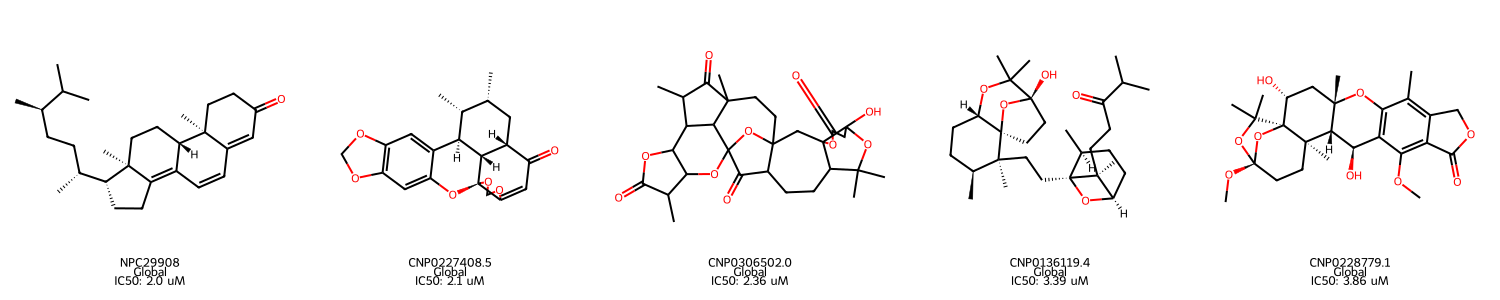

In [12]:


# ==============================================================================
# CELDA 8: REPORTE INTERACTIVO AGRUPADO Y CLASIFICACIÓN GEOGRÁFICA
# ==============================================================================
import pandas as pd
import numpy as np
from IPython.display import display, HTML
from rdkit import Chem
from rdkit.Chem import Draw

print("📊 GENERANDO REPORTE INTERACTIVO AGRUPADO...")

# 1. Cargar el reporte
ruta_reporte = '/home/pedro/QSAR_Project/04_Cribado_Virtual/Reporte_Final_Botanico.csv'
df_final = pd.read_csv(ruta_reporte)

# 2. Motor de Clasificación Geográfica
def categorizar_region(fila):
    ubi = str(fila['Ubicacion']).lower()
    origen = str(fila['Origen']).lower()
    
    paises_latam = {
        'colombia': 'Colombia', 'brasil': 'Brasil', 'brazil': 'Brasil', 
        'mexico': 'México', 'méxico': 'México', 'peru': 'Perú', 'perú': 'Perú', 
        'argentina': 'Argentina', 'chile': 'Chile', 'ecuador': 'Ecuador', 
        'costa rica': 'Costa Rica', 'panama': 'Panamá', 'panamá': 'Panamá', 
        'venezuela': 'Venezuela', 'bolivia': 'Bolivia'
    }
    
    for clave, nombre_oficial in paises_latam.items():
        if clave in ubi: return nombre_oficial
            
    if 'lanapdb' in origen: return 'Latinoamérica (General)'
    return 'Global'

df_final['Region_LatAm'] = df_final.apply(categorizar_region, axis=1)

# 3. Agrupar por Molécula Única
agrupacion = df_final.groupby(['Molecula_ID', 'SMILES', 'Origen', 'Region_LatAm', 
                               'Es_Farmaco_Ideal', 'Alerta_Toxica', 'Reino', 'Especie_o_Fuente'])

df_agrupado = agrupacion.agg(
    Blancos_Atacados=('Blanco', lambda x: ', '.join(sorted(set(x)))),
    Num_Blancos=('Blanco', 'nunique'),
    IC50_Promedio_uM=('IC50_estimado_uM', 'mean')
).reset_index()

# Redondear el IC50 para estética
df_agrupado['IC50_Promedio_uM'] = df_agrupado['IC50_Promedio_uM'].round(2)

# 4. Ordenar: Primero los fármacos ideales, luego por mayor número de blancos, luego por potencia
df_agrupado = df_agrupado.sort_values(
    by=['Es_Farmaco_Ideal', 'Num_Blancos', 'IC50_Promedio_uM'], 
    ascending=[False, False, True]
)

print(f"🏆 TOTAL DE MOLÉCULAS ÚNICAS MULTI-DIANA: {len(df_agrupado)}")
farmacos_reales = df_agrupado[df_agrupado['Es_Farmaco_Ideal'] == True]
print(f"🛡️ SUPERVIVIENTES ADMET (Fármacos Ideales Seguros): {len(farmacos_reales)}\n")

# 5. Visualización de la Tabla Interactiva (Ocultando SMILES para no alargar la tabla)
columnas_vista = ['Molecula_ID', 'Region_LatAm', 'Blancos_Atacados', 'Num_Blancos', 
                  'IC50_Promedio_uM', 'Es_Farmaco_Ideal', 'Alerta_Toxica', 'Especie_o_Fuente']

html_table = df_agrupado[columnas_vista].to_html(index=False, classes='table table-striped', justify='center')
html_code = f"""
<div style="max-height: 400px; overflow-y: auto; border: 2px solid #ccc; padding: 10px; border-radius: 5px; background-color: white;">
    {html_table}
</div>
"""
display(HTML(html_code))

# 6. Dibujar las estructuras de los 5 MEJORES FÁRMACOS IDEALES
print("\n🔬 ESTRUCTURAS 2D DE LOS 5 MEJORES CANDIDATOS (Seguros y Potentes):")

if not farmacos_reales.empty:
    top_5 = farmacos_reales.head(5)
else:
    print("⚠️ Ninguno pasó el filtro ADMET. Mostrando los 5 más potentes de la lista general.")
    top_5 = df_agrupado.head(5)

mols = [Chem.MolFromSmiles(smiles) for smiles in top_5['SMILES']]
leyendas = [f"{row['Molecula_ID']}\n{row['Region_LatAm']}\nIC50: {row['IC50_Promedio_uM']} uM" for _, row in top_5.iterrows()]

img = Draw.MolsToGridImage(mols, molsPerRow=5, subImgSize=(300, 300), legends=leyendas)
display(img)

📊 GENERANDO TABLA DE LOS MEJORES CANDIDATOS...


Molecula_ID,Region_LatAm,Blancos_Atacados,Num_Blancos,IC50_Promedio_uM,Es_Farmaco_Ideal,Alerta_Toxica,Especie_o_Fuente
NPC29908,Global,"Cruzaina, T_cruzi_Amastigote, T_cruzi_Epimastigote, T_cruzi_General, T_cruzi_Tripomastigote, Trans_sialidasa, Tripanotion_reductasa",7,2.00,True,Ninguna,Ref Org: n.a.
CNP0227408.5,Global,"Cruzaina, T_cruzi_Amastigote, T_cruzi_Epimastigote, T_cruzi_General, T_cruzi_Tripomastigote, Trans_sialidasa, Tripanotion_reductasa",7,2.10,True,Ninguna,Saururus chinensis
CNP0306502.0,Global,"Cruzaina, T_cruzi_Amastigote, T_cruzi_Epimastigote, T_cruzi_General, T_cruzi_Tripomastigote, Trans_sialidasa, Tripanotion_reductasa",7,2.36,True,Ninguna,Schisandra chinensis
CNP0136119.4,Global,"Cruzaina, T_cruzi_Amastigote, T_cruzi_Epimastigote, T_cruzi_General, T_cruzi_Tripomastigote, Trans_sialidasa, Tripanotion_reductasa",7,3.39,True,Ninguna,Axinella weltneri
CNP0228779.1,Global,"Cruzaina, T_cruzi_Amastigote, T_cruzi_Epimastigote, T_cruzi_General, T_cruzi_Tripomastigote, Trans_sialidasa, Tripanotion_reductasa",7,3.86,True,Ninguna,Aplysia angasi|Aspergillus|Aspergillus sp.|Carex folliculata|Cercospora ligustri|Cocculus pendulus|Cosmos bipinnatus|Dendroctonus brevicomis|Dictyostelium brefeldianum|Glycosmis parviflora|Hypoxis filiformis|Ipomoea tuberosa|Madhuca utilis|Magnolia baillonii|Phyllanthus maderaspatensis|Pimelea simplex|Piper lolot
CNP0503546.2,Global,"Cruzaina, T_cruzi_Amastigote, T_cruzi_Epimastigote, T_cruzi_General, T_cruzi_Tripomastigote, Trans_sialidasa, Tripanotion_reductasa",7,4.20,True,Ninguna,Lyngbya majuscula
CNP0518898.1,Global,"Cruzaina, T_cruzi_Amastigote, T_cruzi_Epimastigote, T_cruzi_General, T_cruzi_Tripomastigote, Trans_sialidasa, Tripanotion_reductasa",7,4.46,True,Ninguna,Ziziphus mauritiana
CNP0216275.1,Global,"Cruzaina, T_cruzi_Amastigote, T_cruzi_Epimastigote, T_cruzi_General, T_cruzi_Tripomastigote, Trans_sialidasa, Tripanotion_reductasa",7,4.64,True,Ninguna,Ancistrocladus tectorius
CNP0196911.5,Global,"Cruzaina, T_cruzi_Amastigote, T_cruzi_Epimastigote, T_cruzi_General, Trans_sialidasa, Tripanotion_reductasa",6,1.22,True,Ninguna,Streptomyces Y-110|Streptomyces carbophilus|Streptomyces carbophilus SANK 62585|Streptomyces xanthochromogenes
NPC290525,Global,"Cruzaina, T_cruzi_Amastigote, T_cruzi_Epimastigote, T_cruzi_General, T_cruzi_Tripomastigote, Tripanotion_reductasa",6,3.01,True,Ninguna,Ref Org: n.a.



🎨 GENERANDO VISUALIZACIÓN 2D DE LOS 5 MEJORES...


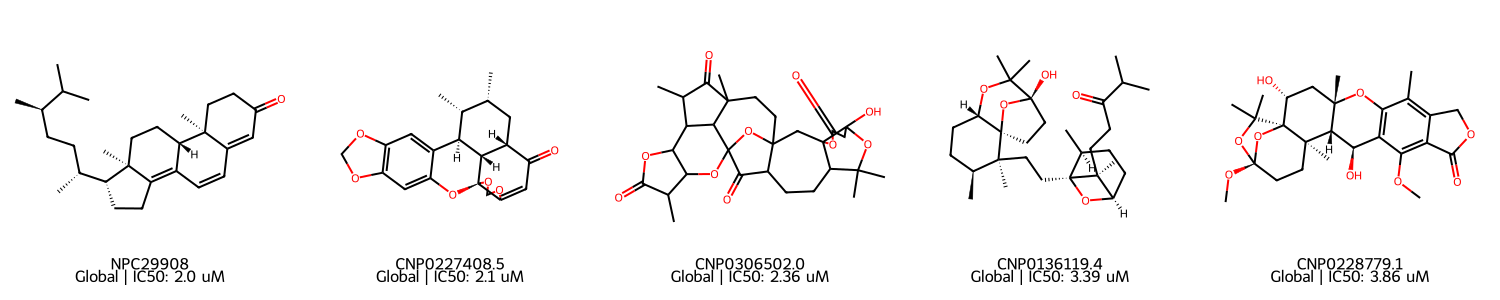


📥 DESCARGANDO ESTRUCTURAS 3D DE PUBCHEM PARA 56 CAMPEONES...
Carpeta de destino: /home/pedro/QSAR_Project/05_Candidatos_Docking_3D
------------------------------------------------------------
✅ ¡PROCESO COMPLETADO!
Estructuras 3D descargadas desde PubChem: 46
Estructuras 3D construidas por IA (RDKit): 10
Tus ligandos están listos en: /home/pedro/QSAR_Project/05_Candidatos_Docking_3D


In [13]:
# ==============================================================================
# CELDA 8: TABLA, VISUALIZACIÓN 2D Y PREPARACIÓN DE ESTRUCTURAS 3D PARA DOCKING
# ==============================================================================
import os
import time
import requests
import urllib.parse
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Draw, AllChem
from IPython.display import display, HTML

print("📊 GENERANDO TABLA DE LOS MEJORES CANDIDATOS...")

# 1. ORDENAR Y PREPARAR LA TABLA INFORMATIVA
df_agrupado = df_agrupado.sort_values(
    by=['Es_Farmaco_Ideal', 'Num_Blancos', 'IC50_Promedio_uM'], 
    ascending=[False, False, True]
)
df_agrupado['IC50_Promedio_uM'] = df_agrupado['IC50_Promedio_uM'].round(2)

columnas_vista = ['Molecula_ID', 'Region_LatAm', 'Blancos_Atacados', 'Num_Blancos', 
                  'IC50_Promedio_uM', 'Es_Farmaco_Ideal', 'Alerta_Toxica', 'Especie_o_Fuente']

html_table = df_agrupado.head(15)[columnas_vista].to_html(index=False, classes='table table-striped', justify='center')
html_code = f"""
<div style="max-height: 400px; overflow-y: auto; border: 2px solid #ccc; padding: 10px; border-radius: 5px; background-color: white;">
    {html_table}
</div>
"""
display(HTML(html_code))

# ==============================================================================
# 2. VISUALIZACIÓN 2D ESTÁTICA Y LIMPIA (Priorizando Nombre_PubChem)
# ==============================================================================
print("\n🎨 GENERANDO VISUALIZACIÓN 2D DE LOS 5 MEJORES...")

farmacos_reales = df_agrupado[df_agrupado['Es_Farmaco_Ideal'] == True]
farmacos_latam = df_agrupado[df_agrupado['Region_LatAm'] != 'Global']

# Priorizar LatAm si hay, sino los mejores generales
top_5 = farmacos_latam.head(5) if not farmacos_latam.empty else (farmacos_reales.head(5) if not farmacos_reales.empty else df_agrupado.head(5))

mols_para_dibujar = []
leyendas = []

for index, row in top_5.iterrows():
    mol = Chem.MolFromSmiles(row['SMILES'])
    if mol:
        AllChem.Compute2DCoords(mol)
        mols_para_dibujar.append(mol)
        
        # Lógica para mostrar el nombre correcto
        nombre_crudo = str(row.get('Nombre_PubChem', row['Molecula_ID']))
        nombre = nombre_crudo[:20] + "..." if len(nombre_crudo) > 20 else nombre_crudo
        leyendas.append(f"{nombre}\n{row['Region_LatAm']} | IC50: {row['IC50_Promedio_uM']} uM")

img = Draw.MolsToGridImage(mols_para_dibujar, molsPerRow=5, subImgSize=(300, 300), legends=leyendas)
display(img)

# ==============================================================================
# 3. DESCARGA AUTOMATIZADA DE ESTRUCTURAS 3D (PREPARACIÓN PARA DOCKING)
# ==============================================================================
carpeta_docking = '/home/pedro/QSAR_Project/05_Candidatos_Docking_3D'
os.makedirs(carpeta_docking, exist_ok=True)

print(f"\n📥 DESCARGANDO ESTRUCTURAS 3D DE PUBCHEM PARA {len(farmacos_reales)} CAMPEONES...")
print(f"Carpeta de destino: {carpeta_docking}")

exitos_pubchem = 0
exitos_rdkit = 0

for index, row in farmacos_reales.iterrows():
    id_mol = str(row['Molecula_ID']).replace("/", "_")
    smiles = row['SMILES']
    ruta_sdf = os.path.join(carpeta_docking, f"{id_mol}.sdf")
    
    # Pausa para no saturar la API de PubChem
    time.sleep(0.3)
    
    # Codificar el SMILES para la URL
    smiles_encoded = urllib.parse.quote(smiles)
    url_pubchem = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/smiles/{smiles_encoded}/SDF?record_type=3d"
    
    try:
        respuesta = requests.get(url_pubchem, timeout=10)
        
        if respuesta.status_code == 200:
            # PubChem tiene el 3D, lo guardamos directamente
            with open(ruta_sdf, 'w') as f:
                f.write(respuesta.text)
            exitos_pubchem += 1
            
        else:
            # Fallback: PubChem no tiene el 3D, lo generamos con RDKit
            mol = Chem.MolFromSmiles(smiles)
            if mol:
                mol_3d = Chem.AddHs(mol)
                params = AllChem.ETKDGv3()
                params.randomSeed = 42
                if AllChem.EmbedMolecule(mol_3d, params) >= 0:
                    AllChem.MMFFOptimizeMolecule(mol_3d)
                    mol_3d.SetProp("_Name", id_mol)
                    writer = Chem.SDWriter(ruta_sdf)
                    writer.write(mol_3d)
                    writer.close()
                    exitos_rdkit += 1
    except Exception as e:
        print(f"Error procesando {id_mol}: {e}")

print("-" * 60)
print(f"✅ ¡PROCESO COMPLETADO!")
print(f"Estructuras 3D descargadas desde PubChem: {exitos_pubchem}")
print(f"Estructuras 3D construidas por IA (RDKit): {exitos_rdkit}")
print(f"Tus ligandos están listos en: {carpeta_docking}")  